In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
from datetime import datetime as dt
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
# import math
# from astropy.convolution import convolve
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')

from ICECAPS_support_functions import *


In [360]:
## SIMBA surface from SIMBA_surface_detection_v2_split_vertical.ipynb
# df = pd.read_csv('/home/asledd/ICECAPS/Raven2024_SIMBA_sfc_id_combined-corrected-maxheight_raw-despiked-72h-05threshold_20250416.csv')
# sfc_fname = 'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_+4cm_v2_20250710.csv'
# sfc_fname = 'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_first-0.2-var-above-max_v2_20250722.csv'
# sfc_fname = 'Raven2024_SIMBA_sfc_id_min-scaled-d2Tdz2_median-daytime-bin_5T-mask_v2.1_20250711.csv'
sfc_fname = 'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_v2_20250723.csv'

# simba_sfc_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['time'].values])       
# simba_sfc_in = df['max_index'].values

df = pd.read_csv('/home/asledd/ICECAPS/'+sfc_fname)
simba_sfc_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['datetime'].values])       
simba_sfc_in = df['surface [cm]'].values

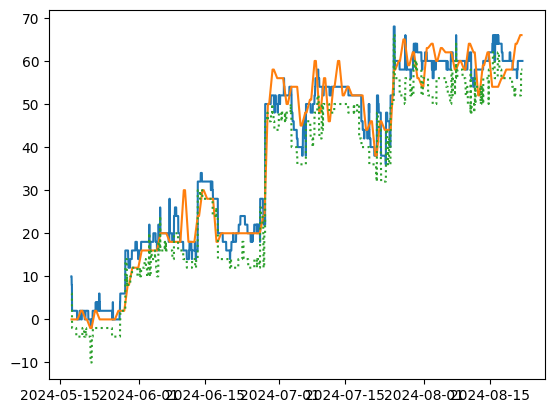

In [361]:
for fn in ['Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_first-0.2-var-above-max_v2_20250722.csv', 'Raven2024_SIMBA_sfc_id_min-scaled-d2Tdz2_median-daytime-bin_5T-mask_v2.1_20250711.csv']:
    df = pd.read_csv('/home/asledd/ICECAPS/'+fn)
    fn_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['datetime'].values])       
    fn_sfc = df['surface [cm]'].values
    plt.plot(fn_dates, fn_sfc)

plt.plot(simba_sfc_dates, simba_sfc_in, ls=':')
plt.show()

In [362]:
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
## new adjusted temps (no smoothing)
# simba_fname = 'firnprofile-combined-corrected.sled.level2.beta.15min.20240517-20240814.nc'
# simba_fname = 'firnprofile-combined-corrected.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc'
simba_fname = 'firnprofile-combined-corrected-at38.sled.level2.beta.15min.20240517-20240821_created_June26_2025.nc'

season_data = {}
varnames = ['temperature','initial_height','time']
fdic = load_netcdf(simba_filepath+simba_fname, varnames)

fstart_time = dt.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')

fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])

for var in ['temperature','dates','initial_height']:
    season_data[var] = fdic[var]

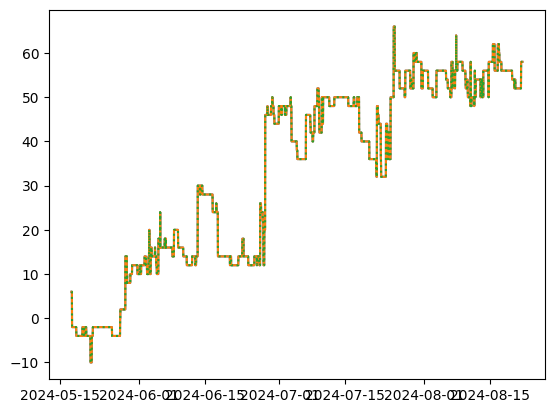

In [376]:
## interpolate simba_sfc to have same timesteps as rest of simba data
sfc_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in simba_sfc_dates])
simba_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in season_data['dates']])

## surface looks too low here
plt.plot(simba_sfc_dates, simba_sfc_in, label='og')
# simba_sfc_in = np.ma.masked_where((simba_sfc_dates>=dt(2024,7,4,1))&(simba_sfc_dates<dt(2024,7,7,2)), simba_sfc_in)
# simba_sfc_in = np.ma.masked_where((simba_sfc_dates>=dt(2024,7,17,1))&(simba_sfc_in<45), simba_sfc_in)

plt.plot(simba_sfc_dates, simba_sfc_in, label='og masked')

f_sfc = interpolate.interp1d(sfc_seconds, simba_sfc_in, fill_value=-999, bounds_error=False)
simba_sfc = f_sfc(simba_seconds)
simba_sfc = np.ma.masked_equal(simba_sfc, -999)

plt.plot(simba_sfc_dates, simba_sfc_in, ls=':')
plt.show()

In [364]:
# turn into function later
asfs_filepath = '/psd3data/arctic/raven_process/asfs/2_level_product/'
asfs_lev2_files = glob.glob(asfs_filepath+'seb.level2.0.melt-sleighsfs.10min.*.nc')

# asfs_filepath = '/psd3data/arctic/raven_process/asfs/2_level_product/full_period/'
# asfs_lev2_files = glob.glob(asfs_filepath+'sleighsfsseb.sleighsfs.level2.0.10min.*.nc')
asfs_lev2_files.sort()
# asfs_lev2_files = asfs_lev2_files[12:] # early files don't have skin_temp_surface?

# vaisala_T_Avg = average of the air temperature during the 1 min averaging interval

lev1_slow_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = {}

for fname in asfs_lev2_files[:]:
    print(fname)

    fdic = load_netcdf(fname, lev1_slow_vars)
    # print(fdic['time_unit'])
    fstart_time = dt.strptime(fdic['time_unit'], 'seconds since %Y-%m-%dT%H:%M:%S.000000')
    fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(seconds=int(m)) for m in fdic['time']])

    for var in lev1_slow_vars[:-2]+['dates']:
        if var not in asfs_data_lev2:
            asfs_data_lev2[var] = fdic[var]
        else:
            asfs_data_lev2[var] = np.ma.concatenate( (asfs_data_lev2[var], fdic[var]), axis=0 )
asfs_data_lev2['net_short_hemisp'] = asfs_data_lev2['down_short_hemisp'] - asfs_data_lev2['up_short_hemisp']
asfs_data_lev2['albedo'] =  asfs_data_lev2['up_short_hemisp']/asfs_data_lev2['down_short_hemisp']

with np.load('/home/asledd/ICECAPS/Raven_SW-correct-tskin_emis985_all-times_20250113.npz') as npz:
    asfs_data_lev2['skin_temp'] = np.ma.MaskedArray(**npz)

/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240520.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240521.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240522.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240523.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240524.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240525.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240526.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240527.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb.level2.0.melt-sleighsfs.10min.20240528.000000.nc
/psd3data/arctic/raven_process/asfs/2_level_product/seb

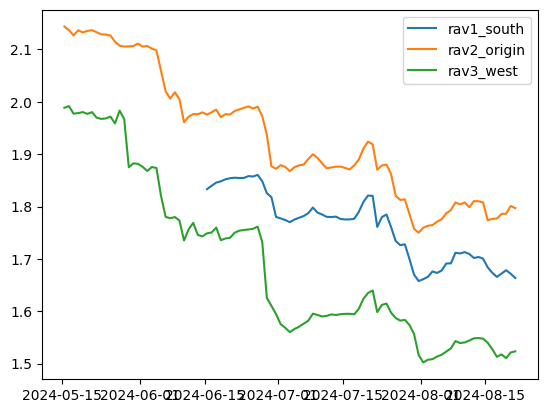

In [365]:
## load OGRE data
fig, ax = plt.subplots(1)
ogre_surface = {}

for ogre in ['rav1_south','rav2_origin','rav3_west']:
    df = pd.read_csv('/psd3data/arctic/sledd/Raven_OGRE/'+ogre+'.csv')
    
    ogre_date = np.array([dt.strptime(d, '%m/%d/%y %H:%M') for d in df['Datetime'].values])       
    ogre_sfc = df[' Average Ant. Height [m]'].values
    ogre_surface[ogre] = {'dates':ogre_date, 'sfc':ogre_sfc}
    ax.plot(ogre_date, ogre_sfc, label=ogre)
ax.legend(loc='best')

plt.show()

Load more data: GPR melt index from Bob and Laura and solar corrected SIMBA

In [366]:
df = pd.read_csv('/psd3data/arctic/sledd/Melt_Index_despiked_GPR_Raven2024.csv')

gpr_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['date'].values])       
gpr_melt = df['Melt_Index_Normal'].values


In [377]:
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
# fn = '/home/asledd/ICECAPS/firnprofile_maxheight_solar-correction_created_20250417.nc'
# fn = 'firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc'
# fn = '/home/asledd/ICECAPS/firnprofile_varaince-sfc_38height-split_solar-correction_created_20250711.nc'

# fn = '/home/asledd/ICECAPS/firnprofile_solar-correction_created_20250722.nc'

simba_corrected_files = {'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_first-0.2-var-above-max_v2_20250722.csv':'firnprofile_solar-correction_rolling-variance-sfc_created_20250722.nc',
                        'Raven2024_SIMBA_sfc_id_min-scaled-d2Tdz2_median-daytime-bin_5T-mask_v2.1_20250711.csv':'firnprofile_solar-correction_max-daytime-d2Tdz2-sfc_created_20250722.nc',
                        'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_v2_20250723.csv':'firnprofile_solar-correction_rolling-variance-max-sfc_created_20250722.nc'}

fn = '/home/asledd/ICECAPS/'+simba_corrected_files[sfc_fname]
print(simba_corrected_files[sfc_fname], sfc_fname)
season_data_solar = {}
if 'firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc' in fn:
    varnames = ['temperature','initial_height','time']
    fdic = load_netcdf(simba_filepath+fn, varnames)
else:
    varnames = ['temp','initial_height','time']
    fdic = load_netcdf(fn, varnames)

if 'firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc'  in fn:
    fstart_time = datetime.datetime.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')
    fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])
else:    
    fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
season_data_solar['seconds'] = fdic['time']

for var in ['temperature','dates','initial_height']:
    if var=='temperature' and ('beta' not in fn):
        season_data_solar['temperature'] = fdic['temp']
    else:
        season_data_solar[var] = fdic[var]

if 'firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc' in fn:
    season_data_solar['height'] = season_data_solar['initial_height'][::-1]
    season_data_solar['temperature'] = season_data_solar['temperature'][:,::-1]
else:
    season_data_solar['height'] = season_data_solar['initial_height']

firnprofile_solar-correction_rolling-variance-max-sfc_created_20250722.nc Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_v2_20250723.csv


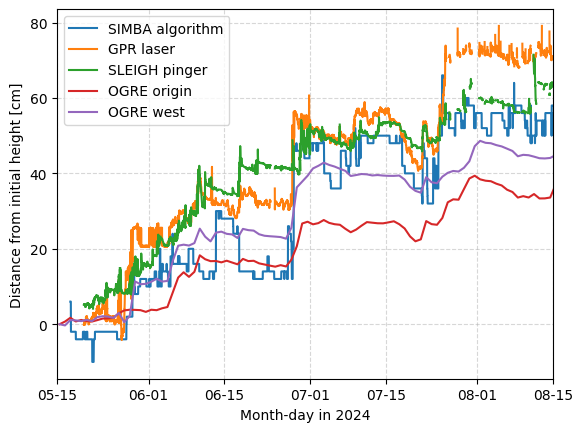

In [378]:
fig, ax = plt.subplots(1)
ax.plot(season_data['dates'], simba_sfc, label='SIMBA algorithm')

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger')

for ogre in ['rav2_origin','rav3_west']:
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., label='OGRE '+ogre.split('_')[-1])

    
ax.legend(loc='best')
ax.grid(alpha=.5, ls='--')
ax.set_ylabel('Distance from initial height [cm]')

ax.set_xlim(dt(2024,5,15),dt(2024,8,15))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# plt.tight_layout()
plt.show()

### Making figure that shows temperaratures above 0 below the surface as well as sifferent surfaces from other instruments

In [379]:
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
# fn = 'firnprofile_maxheight_solar-correction_created_20250417.nc'
fn = 'firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc'

season_data_unc = {}
if fn=='firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc':
    varnames = ['temperature','initial_height','time']
    fdic = load_netcdf(simba_filepath+fn, varnames)
else:
    varnames = ['temp','initial_height','time']
    fdic = load_netcdf(fn, varnames)

if fn=='firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc':
    fstart_time = datetime.datetime.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')
    fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])
else:    
    fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
season_data_unc['seconds'] = fdic['time']

for var in ['temperature','dates','initial_height']:
    if var=='temperature' and fn=='firnprofile_maxheight_solar-correction_created_20250417.nc':
        season_data_unc['temperature'] = fdic['temp']
    else:
        season_data_unc[var] = fdic[var]

if fn=='firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc':
    season_data_unc['height'] = season_data_unc['initial_height'][::-1]
    season_data_unc['temperature'] = season_data_unc['temperature'][:,::-1]
else:
    season_data_unc['height'] = season_data_unc['initial_height']

In [380]:
plrams_fpath = '/home/asledd/ICECAPS/polarAMS2025/'

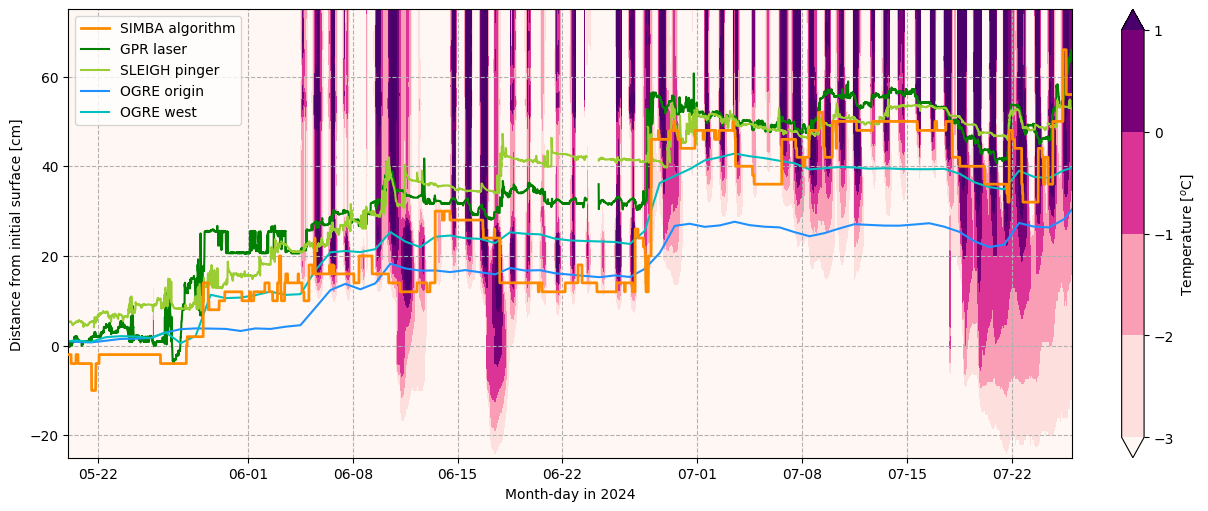

In [381]:
# plt.rcParams.update({'font.size': 10})

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(season_data_unc['temperature'],0,1),
                cmap=cmap, levels=np.arange(-3,2,1), extend='both')
# ax.contour(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(season_data_unc['temperature'],0,1),
#                 levels=[1], extend='both')
plt.colorbar(cb, ax=ax, label='Temperature [$^o$C]')

ax.grid(ls='--')

ax.plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='darkorange', lw=2, zorder=10)

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)

ax.legend(loc='upper left')

ax.set_ylabel('Distance from initial surface [cm]')
ax.set_ylim(-25, 75)

ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,26))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

In [382]:
second_vert_grad = np.gradient(np.gradient(season_data_unc['temperature'], season_data_unc['height'], axis=1),axis=1)

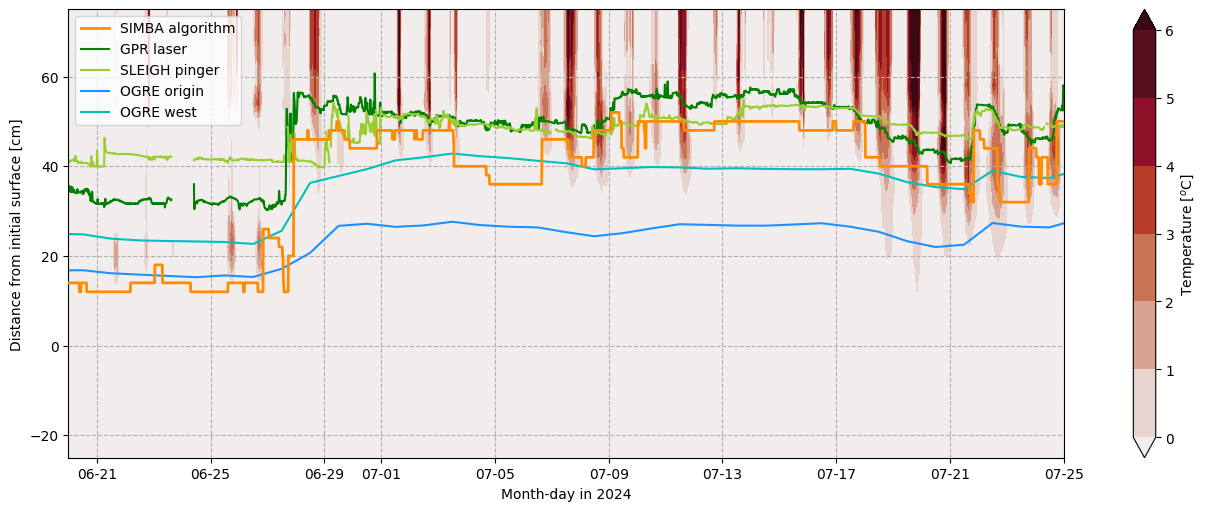

In [383]:
# plt.rcParams.update({'font.size': 10})

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)


cmap = cmocean.cm.amp
cb = ax.contourf(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(season_data_unc['temperature'],0,1),
                cmap=cmap, levels=np.arange(0,7,1), extend='both')
# ax.contour(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(season_data_unc['temperature'],0,1),
#                 levels=[1], extend='both')
plt.colorbar(cb, ax=ax, label='Temperature [$^o$C]')

ax.grid(ls='--')

ax.plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='darkorange', lw=2, zorder=10)

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)

ax.legend(loc='upper left')

ax.set_ylabel('Distance from initial surface [cm]')
ax.set_ylim(-25, 75)

ax.set_xlim(datetime.datetime(2024,6,20),datetime.datetime(2024,7,25))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

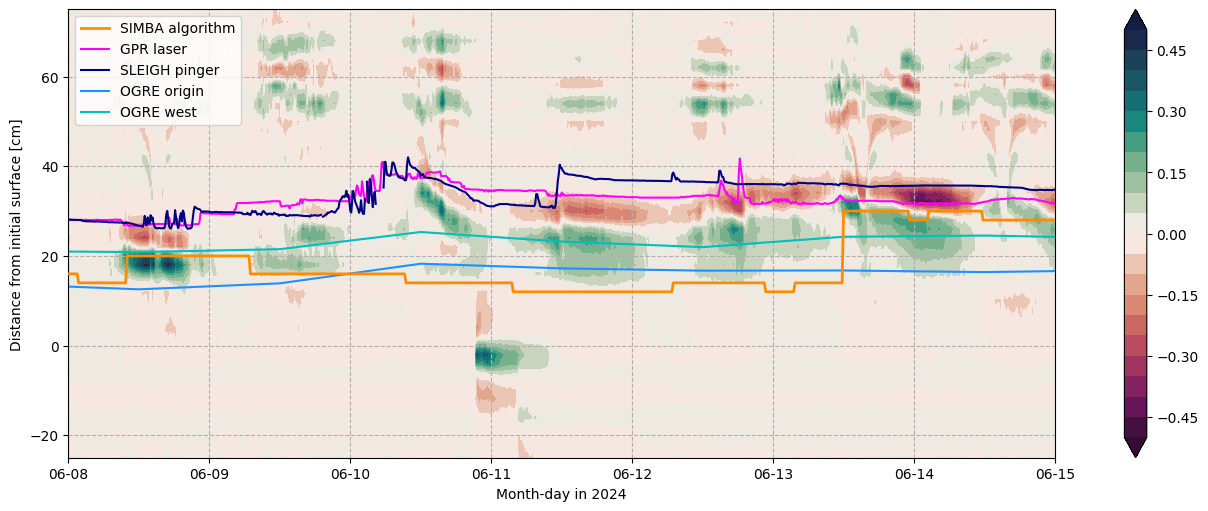

In [384]:
# plt.rcParams.update({'font.size': 10})

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)


cmap = cmocean.cm.curl_r
cb = ax.contourf(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(second_vert_grad,0,1),
                cmap=cmap, levels=np.arange(-.5,.51,.05), extend='both')
# ax.contour(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(season_data_unc['temperature'],0,1),
#                 levels=[1], extend='both')
plt.colorbar(cb, ax=ax, label='')

ax.grid(ls='--')

ax.plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='darkorange', lw=2, zorder=10)

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., 
        label='GPR laser', c='magenta')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='navy')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)

ax.legend(loc='upper left')

ax.set_ylabel('Distance from initial surface [cm]')
ax.set_ylim(-25, 75)

# ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,6,1))

ax.set_xlim(datetime.datetime(2024,6,8),datetime.datetime(2024,6,15))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

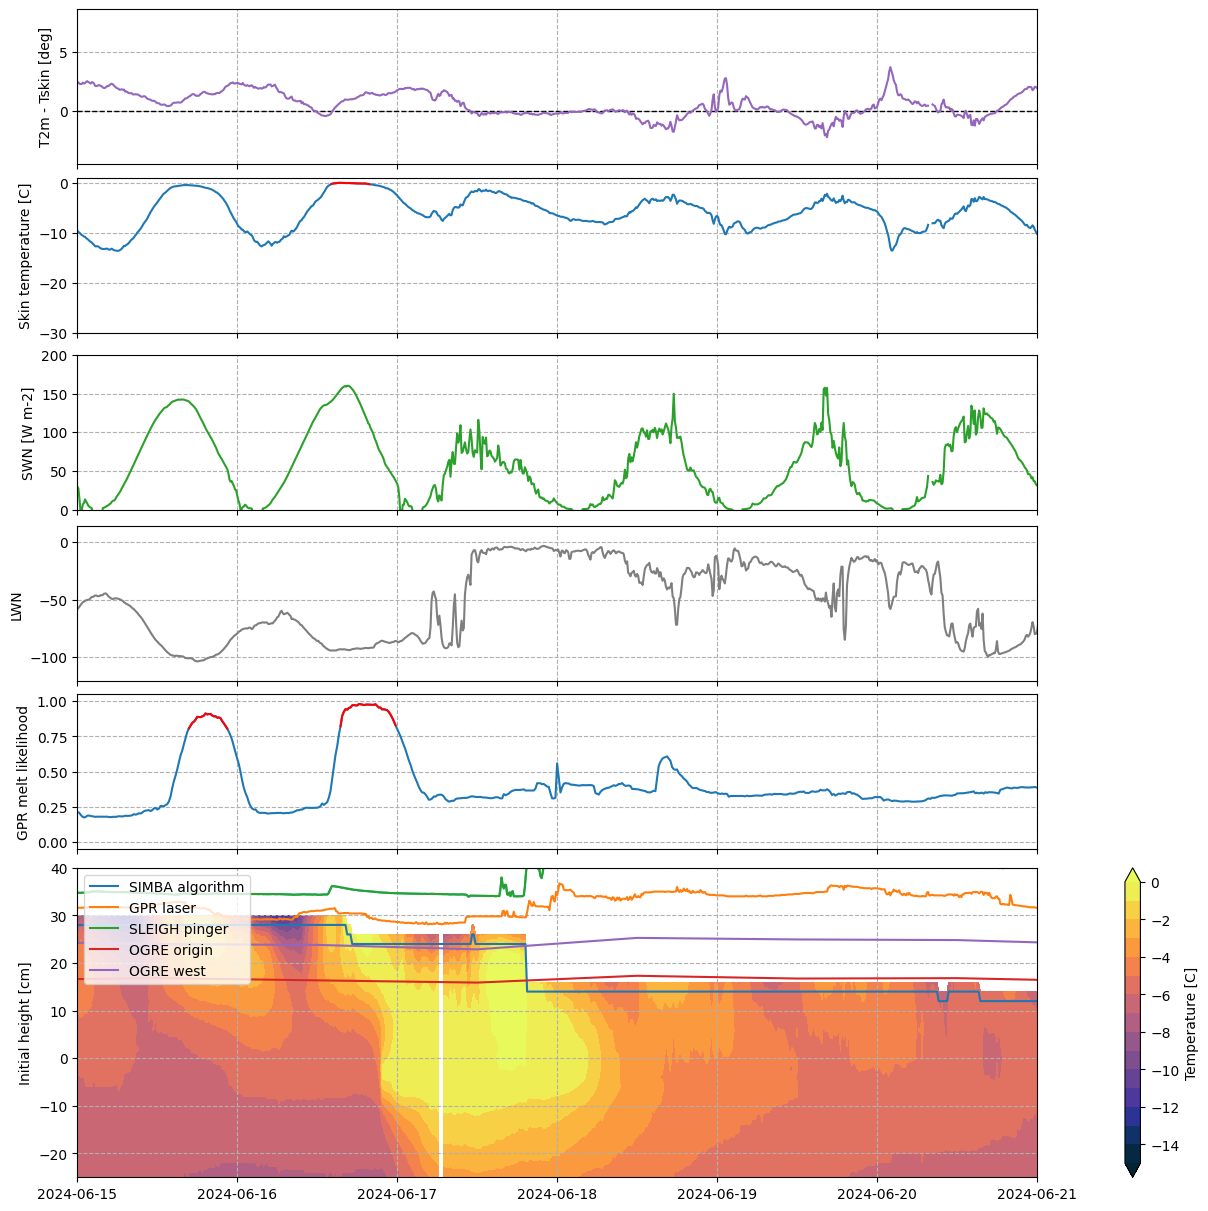

In [385]:
fig, axs = plt.subplots(6, figsize=(12,12), constrained_layout=True, 
                        sharex=True, gridspec_kw=dict(height_ratios=[1,1,1,1,1,2]))


# cb = axs[-1].contourf(season_data['dates'], season_data['height'], np.swapaxes(season_data['temperature'],0,1),
#                 cmap=plt.cm.OrRd, levels=np.arange(-3,4,1), extend='both')
# plt.colorbar(cb, ax=axs[-1], label='Temperature [C]')
# cb = axs[-1].contour(season_data['dates'], season_data['height'], np.swapaxes(season_data['temperature'],0,1),
#                 levels=[0], extend='both', lw=1)
# axs[-1].set_ylabel('Distance from top of SIMBA [cm]')

# ax.axhline(y=-350, c='r', ls='--') ## initial thermistor at the surface when the instrument was installed
for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--')

axs[1].plot(asfs_data_lev2['dates'], asfs_data_lev2['skin_temp']-273.15)
axs[1].plot(asfs_data_lev2['dates'], np.ma.masked_less(asfs_data_lev2['skin_temp']-273.15, -0.32), c='r')
axs[1].set_ylabel('Skin temperature [C]')

axs[0].axhline(y=0, c='k', ls='--', lw=1)
axs[0].plot(asfs_data_lev2['dates'], asfs_data_lev2['temp']-(asfs_data_lev2['skin_temp']-273.15), c='tab:purple')
axs[0].set_ylabel('T2m - Tskin [deg]')

axs[2].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_short_hemisp']-asfs_data_lev2['up_short_hemisp'], c='tab:green')
axs[2].set_ylabel('SWN [W m-2]')


# axs[3].plot(asfs_data_lev2['dates'], albedo, lw=1)
# axs[3].plot(asfs_data_lev2['dates'], albedo_smoothed,)

# axs[3].set_ylabel('SWU/SWD')
# axs[3].set_ylim(0.6,1)

# axs[0].set_xlim(datetime.datetime(2024,7,18),datetime.datetime(2024,7,25))
axs[1].set_ylim(-30,1)
# axs[1].set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,25))



axs[3].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_long_hemisp']-asfs_data_lev2['up_long_hemisp'], c='tab:gray')
axs[3].set_ylabel('LWN')

axs[4].plot(gpr_dates, gpr_melt)
axs[4].plot(gpr_dates, np.ma.masked_less(gpr_melt,.8), c='r')
axs[4].set_ylabel('GPR melt likelihood')


# axs[-1].plot(plt_times, 100.*rnd_sfc-32, color='gray')
# axs[-1].plot(plt_times, 100*rnd_sfc, c='k')
axs[-1].plot(asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], c='c')
axs[-1].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm')

cb = axs[-1].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(season_data_solar['temperature'],0,1),
                cmap=cmocean.cm.thermal, levels=np.arange(-15,0.5,1), extend='both')
# axs[1].contour(simba_dates, simba_depths, np.swapaxes(corrected_temps_new,0,1),
#                 levels=[0], extend='both')
plt.colorbar(cb, ax=axs[-1], label='Temperature [C]')

axs[-1].set_ylim(-120,65)
axs[-1].set_ylabel('Initial height [cm]')

axs[-1].plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser')
axs[-1].plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger')

for ogre in ['rav2_origin','rav3_west']:
    axs[-1].plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., label='OGRE '+ogre.split('_')[-1])

axs[-1].legend(loc='upper left')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
axs[2].set_ylim(0,200)
# axs[-1].set_ylim(-380, -270)
# plt.savefig('/home/asledd/ICECAPS/figures/Raven_skinT_SWN_albedo_LWN_deltaT_temp-contour_20240601-20240725.png', dpi=250)

axs[1].set_xlim(datetime.datetime(2024,6,15),datetime.datetime(2024,6,21))
axs[-1].set_ylim(-25,40)

plt.show()

### Make multi-panel plots to put all varibales together for melt stories

In [386]:
simba_temp_masked = np.ma.masked_outside(np.ma.masked_invalid(season_data_solar['temperature']), -50,5)
simba_temp_masked_unc = np.ma.masked_outside(np.ma.masked_invalid(season_data_unc['temperature']), -50,5)


unc_idx = np.where( (season_data_unc['dates']>=season_data_solar['dates'][0])&(season_data_unc['dates']<=season_data_solar['dates'][-1]) )[0]
simba_temp_masked_unc = simba_temp_masked_unc[unc_idx,:]

In [387]:
temp_vert_grad = np.gradient(simba_temp_masked, season_data_solar['height'], axis=1)
temp_vert_grad_unc = np.gradient(simba_temp_masked_unc, season_data_unc['height'], axis=1)

temp_vert_grad_one_side = temp_vert_grad[:,:-1] - temp_vert_grad[:,1:]

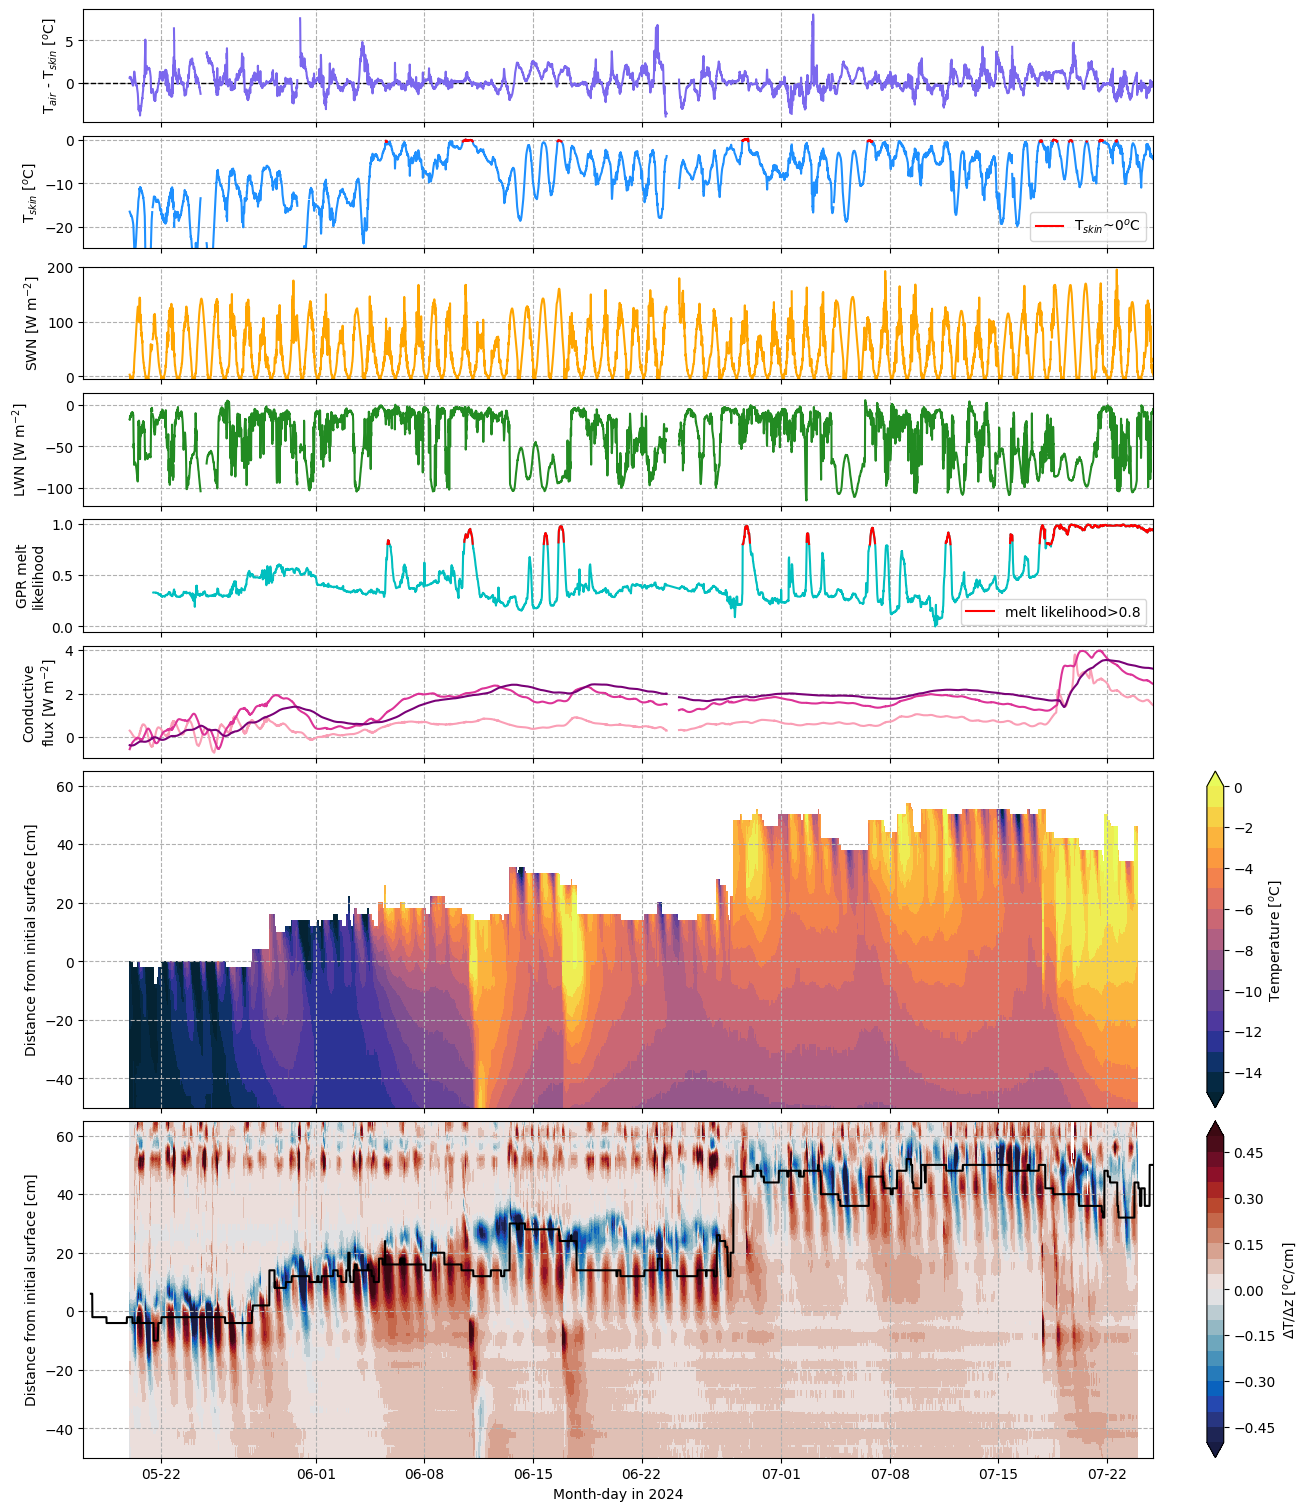

In [388]:
fig, axs = plt.subplots(8, figsize=(13,15), constrained_layout=True, 
                        sharex=True, gridspec_kw=dict(height_ratios=[1,1,1,1,1,1,3,3]))


for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--')

axs[1].plot(asfs_data_lev2['dates'], asfs_data_lev2['skin_temp']-273.15, c='dodgerblue')
axs[1].plot(asfs_data_lev2['dates'], np.ma.masked_less(asfs_data_lev2['skin_temp']-273.15, -0.32), c='r', label='T$_{skin}$~0$^o$C')
axs[1].set_ylabel('T$_{skin}$ [$^o$C]')

axs[0].axhline(y=0, c='k', ls='--', lw=1)
axs[0].plot(asfs_data_lev2['dates'], asfs_data_lev2['temp']-(asfs_data_lev2['skin_temp']-273.15), c='mediumslateblue')
axs[0].set_ylabel('T$_{air}$ - T$_{skin}$ [$^o$C]')

axs[2].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_short_hemisp']-asfs_data_lev2['up_short_hemisp'], c='orange')
axs[2].set_ylabel('SWN [W m$^{-2}$]')

axs[1].set_ylim(-25,1)


# axs[1].set_xlim(dt(2024,6,8),dt(2024,6,22))
# axs[1].set_xlim(dt(2024,6,16),dt(2024,7,1))
axs[1].set_xlim(dt(2024,5,17),dt(2024,7,25))

axs[3].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_long_hemisp']-asfs_data_lev2['up_long_hemisp'], c='forestgreen')
axs[3].set_ylabel('LWN [W m$^{-2}$]')

axs[4].plot(gpr_dates, gpr_melt, c='c')
axs[4].plot(gpr_dates, np.ma.masked_less(gpr_melt,.8), c='r', label='melt likelihood>0.8')
axs[4].set_ylabel('GPR melt\nlikelihood')

for fp, c in zip(['A','B','C'],['#FA9EB5','#DC3397','#790177']):
    axs[5].plot(asfs_data_lev2['dates'], asfs_data_lev2['subsurface_heat_flux_'+fp], c=c)
axs[5].set_ylabel('Conductive\nflux [W m$^{-2}$]')


# axs[-1].plot(plt_times, 100.*rnd_sfc-32, color='gray')
# axs[-1].plot(plt_times, 100*rnd_sfc, c='k')
# axs[-1].plot(asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], c='c')
# axs[-1].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm')

cb = axs[-2].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(season_data_solar['temperature'],0,1),
                cmap=cmocean.cm.thermal, levels=np.arange(-15,0.5,1), extend='both')
# axs[1].contour(simba_dates, simba_depths, np.swapaxes(corrected_temps_new,0,1),
#                 levels=[0], extend='both')
plt.colorbar(cb, ax=axs[-2], label='Temperature [$^o$C]')


# plt.cm.BrBG
cb = axs[-1].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(temp_vert_grad_unc,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.5,.51,.05), extend='both')
plt.colorbar(cb, ax=axs[-1], label='$\Delta$T/$\Delta$z [$^o$C/cm]')
axs[-1].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='k')

for i in [-1, -2]:
    axs[i].set_ylim(-50,65)
    axs[i].set_ylabel('Distance from initial surface [cm]')

# axs[-1].plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser')
# axs[-1].plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger')

# for ogre in ['rav2_origin','rav3_west']:
#     axs[-1].plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., label='OGRE '+ogre.split('_')[-1])

for i in [1,4]:
    axs[i].legend(loc='lower right')

axs[2].set_ylim(-5,200)

axs[-1].xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')

# plt.savefig(plrams_fpath+'Raven_stacked-timeseries_July15-25_poster.png', dpi=300)

plt.show()

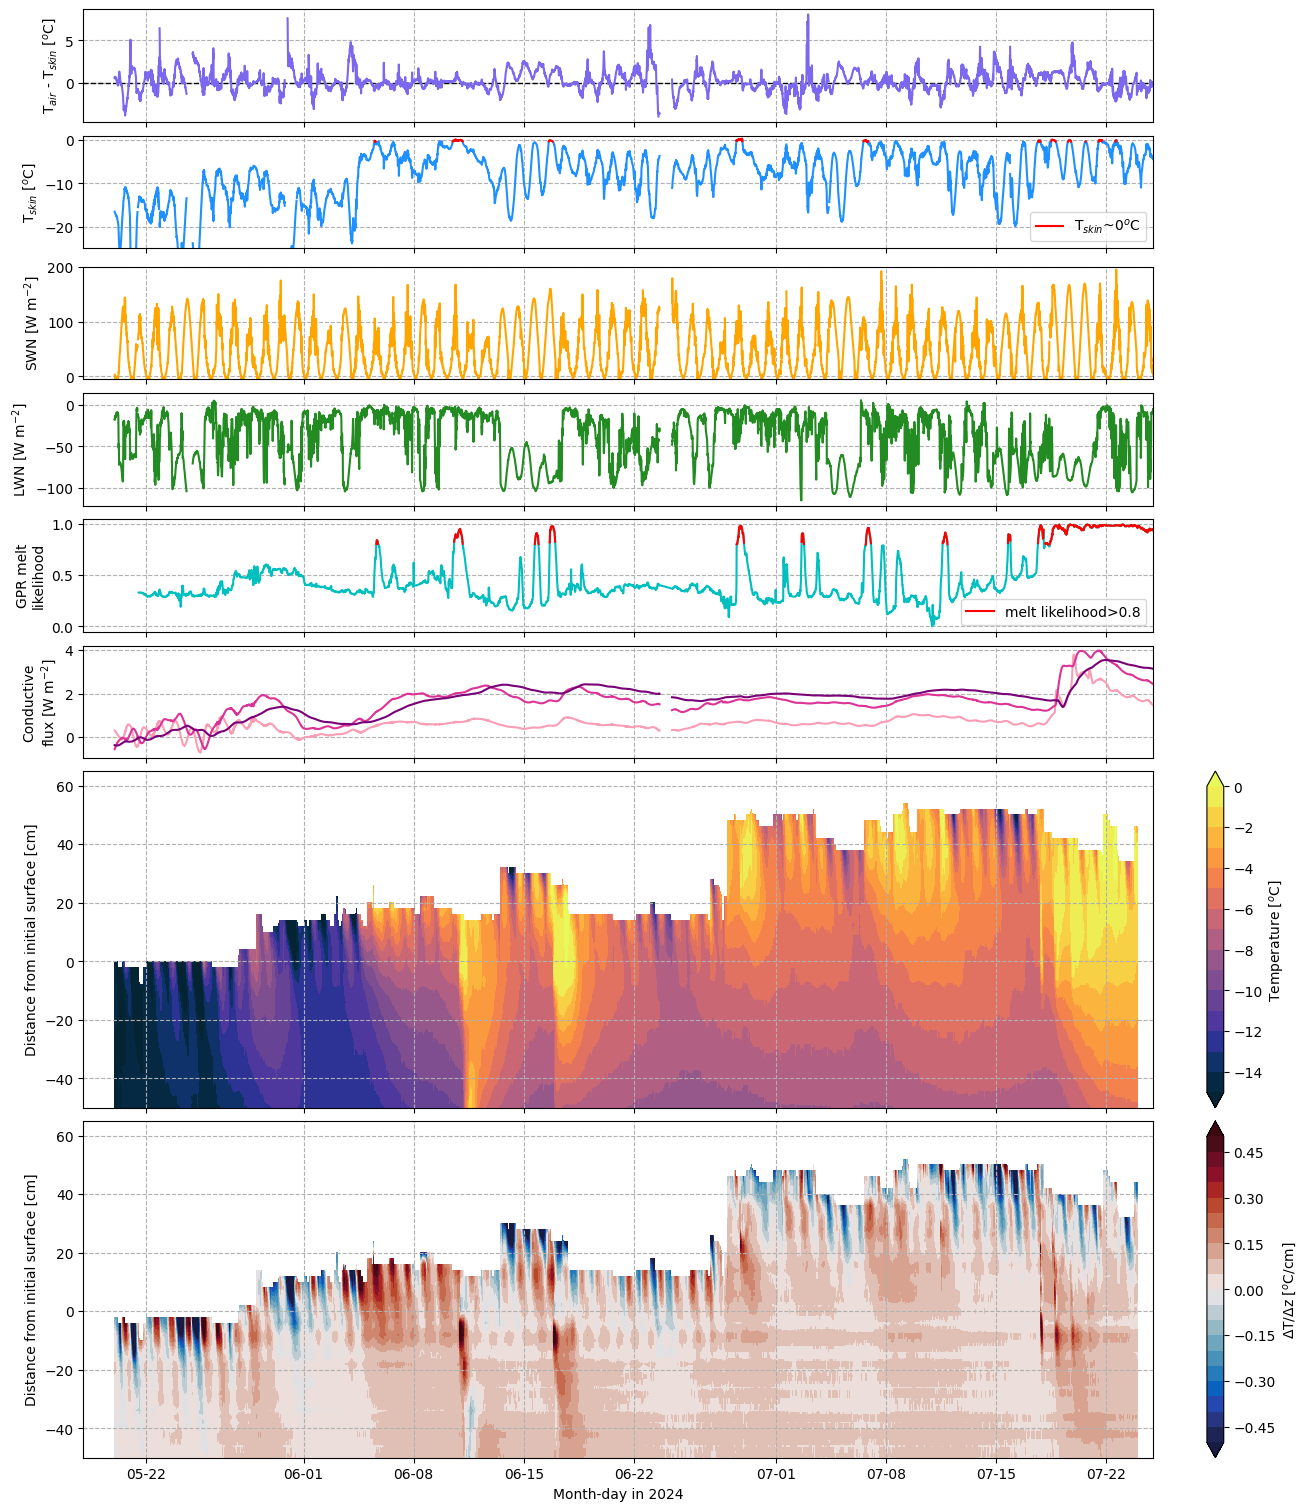

In [389]:
fig, axs = plt.subplots(8, figsize=(13,15), constrained_layout=True, 
                        sharex=True, gridspec_kw=dict(height_ratios=[1,1,1,1,1,1,3,3]))


for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--')

axs[1].plot(asfs_data_lev2['dates'], asfs_data_lev2['skin_temp']-273.15, c='dodgerblue')
axs[1].plot(asfs_data_lev2['dates'], np.ma.masked_less(asfs_data_lev2['skin_temp']-273.15, -0.32), c='r', label='T$_{skin}$~0$^o$C')
axs[1].set_ylabel('T$_{skin}$ [$^o$C]')

axs[0].axhline(y=0, c='k', ls='--', lw=1)
axs[0].plot(asfs_data_lev2['dates'], asfs_data_lev2['temp']-(asfs_data_lev2['skin_temp']-273.15), c='mediumslateblue')
axs[0].set_ylabel('T$_{air}$ - T$_{skin}$ [$^o$C]')

axs[2].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_short_hemisp']-asfs_data_lev2['up_short_hemisp'], c='orange')
axs[2].set_ylabel('SWN [W m$^{-2}$]')

axs[1].set_ylim(-25,1)


axs[1].set_xlim(dt(2024,5,18),dt(2024,7,25))
# axs[1].set_xlim(dt(2024,6,6),dt(2024,6,19))

# axs[1].set_xlim(dt(2024,6,16),dt(2024,7,1))

# axs[1].set_xlim(dt(2024,7,15),dt(2024,7,25))

axs[3].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_long_hemisp']-asfs_data_lev2['up_long_hemisp'], c='forestgreen')
axs[3].set_ylabel('LWN [W m$^{-2}$]')

axs[4].plot(gpr_dates, gpr_melt, c='c')
axs[4].plot(gpr_dates, np.ma.masked_less(gpr_melt,.8), c='r', label='melt likelihood>0.8')
axs[4].set_ylabel('GPR melt\nlikelihood')

for fp, c in zip(['A','B','C'],['#FA9EB5','#DC3397','#790177']):
    axs[5].plot(asfs_data_lev2['dates'], asfs_data_lev2['subsurface_heat_flux_'+fp], c=c)
axs[5].set_ylabel('Conductive\nflux [W m$^{-2}$]')


# axs[-1].plot(plt_times, 100.*rnd_sfc-32, color='gray')
# axs[-1].plot(plt_times, 100*rnd_sfc, c='k')
# axs[-1].plot(asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], c='c')
# axs[-1].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm')

cb = axs[-2].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(season_data_solar['temperature'],0,1),
                # cmap=cmocean.cm.thermal, levels=np.arange(-15,0.5,1), extend='both')
                cmap=cmocean.cm.thermal, levels=np.arange(-15,0.1,1), extend='both')

# axs[1].contour(simba_dates, simba_depths, np.swapaxes(corrected_temps_new,0,1),
#                 levels=[0], extend='both')
plt.colorbar(cb, ax=axs[-2], label='Temperature [$^o$C]')

cb = axs[-1].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(temp_vert_grad,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.5,.51,.05), extend='both')

# cb = axs[-1].contourf(season_data_solar['dates'], season_data_solar['height'][:-1], np.swapaxes(temp_vert_grad_one_side,0,1)/100.,
#                 cmap=cmocean.cm.balance, levels=np.arange(-.5,.51,.05), extend='both')



plt.colorbar(cb, ax=axs[-1], label='$\Delta$T/$\Delta$z [$^o$C/cm]')

for i in [-1, -2]:
    axs[i].set_ylim(-50,65)
    axs[i].set_ylabel('Distance from initial surface [cm]')

# axs[-1].plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser')
# axs[-1].plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger')

# for ogre in ['rav2_origin','rav3_west']:
#     axs[-1].plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., label='OGRE '+ogre.split('_')[-1])

for i in [1,4]:
    axs[i].legend(loc='lower right')

axs[2].set_ylim(-5,200)

axs[-1].xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')

# plt.savefig(plrams_fpath+'Raven_stacked-timeseries_Jun10-20.png', dpi=300)

plt.show()

#### save figures to explain dT/dz concerns

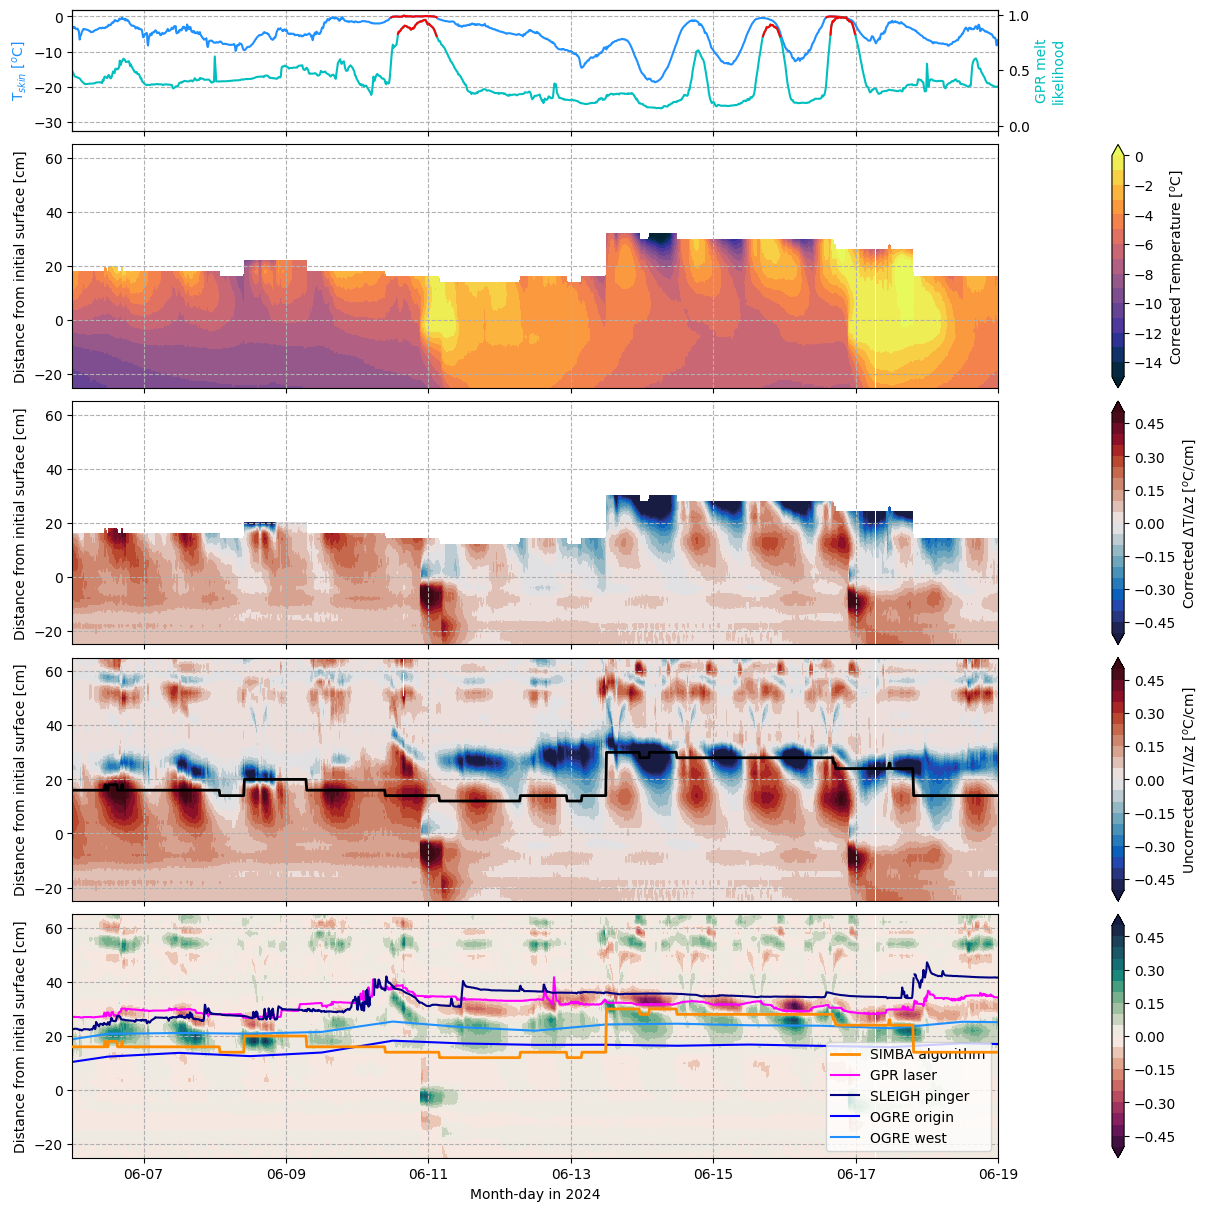

In [390]:
fig, axs = plt.subplots(5, figsize=(12,12), constrained_layout=True, 
                        sharex=True, gridspec_kw=dict(height_ratios=[1,2,2,2,2]))


for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--')


axs[0].plot(asfs_data_lev2['dates'], asfs_data_lev2['skin_temp']-273.15, c='dodgerblue')
axs[0].plot(asfs_data_lev2['dates'], np.ma.masked_less(asfs_data_lev2['skin_temp']-273.15, -0.32), c='r', label='T$_{skin}$~0$^o$C')
axs[0].set_ylabel('T$_{skin}$ [$^o$C]', color='dodgerblue')

axtwin = axs[0].twinx()
axtwin.plot(gpr_dates, gpr_melt, c='c')
axtwin.plot(gpr_dates, np.ma.masked_less(gpr_melt,.8), c='r', label='melt likelihood>0.8')
axtwin.set_ylabel('GPR melt\nlikelihood', color='c')


cb = axs[1].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(season_data_solar['temperature'],0,1),
                cmap=cmocean.cm.thermal, levels=np.arange(-15,0.1,1), extend='both')
plt.colorbar(cb, ax=axs[1], label='Corrected Temperature [$^o$C]')

cb = axs[2].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(temp_vert_grad,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.5,.51,.05), extend='both')
plt.colorbar(cb, ax=axs[2], label='Corrected $\Delta$T/$\Delta$z [$^o$C/cm]')


cb = axs[3].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(temp_vert_grad_unc,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.5,.51,.05), extend='both')
plt.colorbar(cb, ax=axs[3], label='Uncorrected $\Delta$T/$\Delta$z [$^o$C/cm]')
axs[3].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='k', lw=2)

cmap = cmocean.cm.curl_r
cb = axs[4].contourf(season_data_unc['dates'], season_data_unc['height'], np.swapaxes(second_vert_grad,0,1),
                cmap=cmap, levels=np.arange(-.5,.51,.05), extend='both')
plt.colorbar(cb, ax=axs[4], label='')

axs[4].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm', c='darkorange', lw=2, zorder=10)
axs[4].plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., 
        label='GPR laser', c='magenta')
axs[4].plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='navy')

for ogre, c in zip(['rav2_origin','rav3_west'],['b', 'dodgerblue']):
    axs[4].plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)

axs[4].legend(loc='lower right')

axs[-1].xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')

# xlimit = (dt(2024,5,20),dt(2024,6,1))
# xlimit = (dt(2024,6,6),dt(2024,6,19))
# xlimit = (dt(2024,7,10),dt(2024,7,25))

axs[1].set_xlim(xlimit)

for i in range(1, len(axs)):
    if xlimit==(dt(2024,5,20),dt(2024,6,1)):
        axs[i].set_ylim(-30,25)
    else:
        axs[i].set_ylim(-25,65)
    axs[i].set_ylabel('Distance from initial surface [cm]')


# axs[1].set_xlim(dt(2024,5,30),dt(2024,6,15))

# axs[1].set_xlim(dt(2024,6,16),dt(2024,7,1))
# plt.tight_layout()
savepath = '/home/asledd/ICECAPS/subsurface_reinvestigation/'
if xlimit==(dt(2024,5,20),dt(2024,6,1)):
    fname = 'Raven_Tskin-GPR_T_dTdz_d2tdz2_May20-Jun1.png'
elif xlimit==(dt(2024,6,16),dt(2024,7,1)):
    fname = 'Raven_Tskin-GPR_T_dTdz_d2tdz2_Jun16-Jul1.png'
elif xlimit==(dt(2024,7,10),dt(2024,7,25)):
    fname = 'Raven_Tskin-GPR_T_dTdz_d2tdz2_Jul10-Jul25.png'
    
# plt.savefig(savepath+fname, dpi=250)
plt.show()

## looking at warming/variability relative to the surface

In [391]:
## calculate warming over each layer
## maybe try to calculate energy accumulated? make some assumptions for density based on snow pits and new snow density...

In [392]:
print(season_data['dates'][-1], season_data_solar['dates'][-1])
sfc_idx = np.where( (season_data['dates']>=season_data_solar['dates'][0])&(season_data['dates']<=season_data_solar['dates'][-1]) )

2024-08-21 23:45:00 2024-07-23 23:45:00


In [393]:
depths_rel_to_sfc = np.repeat(season_data_solar['height'].copy()[np.newaxis,:], season_data_solar['temperature'].shape[0], axis=0)

sfc_2d = np.ma.repeat(simba_sfc[sfc_idx[0],np.newaxis], season_data_solar['temperature'].shape[1], axis=1)
depths_rel_to_sfc = depths_rel_to_sfc-sfc_2d

In [394]:
temporary_temp = np.ma.masked_where(depths_rel_to_sfc>0, season_data_solar['temperature'])# temporary temperature

temps_rel_to_sfc = []

m = 100 # size of 

for i in range(temporary_temp.shape[0]):
    temp_i = temporary_temp[i,:-1]
    sub_t = temp_i[~temp_i.mask]

    sub_t_filled = np.ma.concatenate( (sub_t, np.full(int(m-sub_t.count()), -999 )) )
    temps_rel_to_sfc.append(sub_t_filled)
    
temps_rel_to_sfc = np.ma.masked_equal(temps_rel_to_sfc, -999)

In [395]:
sub_depths = np.arange(0,temps_rel_to_sfc.shape[1])
sub_depths *= -2

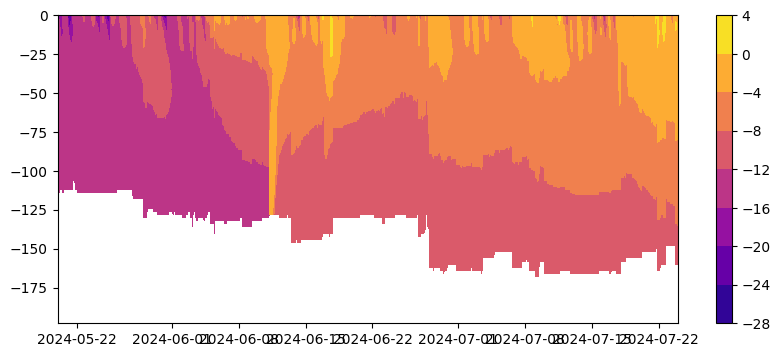

In [396]:
fig, axs = plt.subplots(1, figsize=(10,4))

cb = plt.contourf(season_data_solar['dates'], sub_depths, np.swapaxes(temps_rel_to_sfc,0,1), cmap='plasma')
# plt.plot(simba_dates, simba_sfc-6.,  c='k')
plt.colorbar(cb)

# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

In [397]:
temps_rel_to_sfc = np.ma.masked_invalid(temps_rel_to_sfc)

In [398]:
temp_counts = temps_rel_to_sfc.count(axis=0)

## std dev w/ depth
temp_std_profile = temps_rel_to_sfc.std(axis=0)

l = temps_rel_to_sfc.count(axis=0)[0]
temp_std_full = np.ma.masked_where(temp_counts<l, temp_std_profile)


## correlations to surface/skin temperature w/ depth
temp_corrs = np.ma.corrcoef(temps_rel_to_sfc[:,0], temps_rel_to_sfc[:,1:].T)[0][1:]
# temp_corrs_skin = np.ma.corrcoef(skinT_sfc_timesteps, temps_rel_to_sfc[:,:].T)[0][1:]

# warming relative to surface - also test warming at each level?
dT_dt_rel_to_sfc = temps_rel_to_sfc[1:,:] - temps_rel_to_sfc[:-1,:]
dT_dt_rel_to_sfc = dT_dt_rel_to_sfc.sum(axis=0)

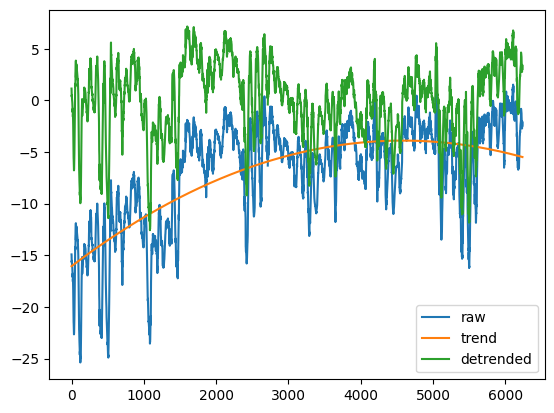

In [399]:
# detrend_temps = scipy.signal.detrend(temps_rel_to_sfc, axis=0)

# detrend_temps = detrend_masked_along_axis(temps_rel_to_sfc, axis=0, type='linear')
# detrend_temps = []


# ## inefficent detrending because there are nans

x = np.arange(temps_rel_to_sfc.shape[0])

slopes_with_depth = []

for i in range(temps_rel_to_sfc.shape[1]):
    y = temps_rel_to_sfc[:,i]

    try:
        coeff = np.ma.polyfit(x, y, 2)
    except:
        detrend_temps = np.ma.concatenate( (detrend_temps, np.full(x.shape, np.nan)[:, np.newaxis]), axis=1 )
        slopes_with_depth.append(np.nan)
        continue
    # no need to use the original x values here just for visualizing the polynomial
    x_poly = np.linspace(x.min(), x.max())
    y_poly = np.polyval(coeff, x_poly)
    
    # we need the original x values here, so we can remove the trend from all points
    trend = np.polyval(coeff, x)
    t_detrend = y - trend
    # note that simply subtracting the trend might not be enough for other data sets
    slopes_with_depth.append(coeff[0])
        
    if i==0:
        detrend_temps = t_detrend[:, np.newaxis]
        ## check detrending
        plt.plot(x, y, label='raw')
        plt.plot(x, trend, label='trend')
        plt.plot(x, t_detrend, label='detrended')
        plt.legend(loc='best')
        plt.show()

    else:
        detrend_temps = np.ma.concatenate( (detrend_temps, t_detrend[:, np.newaxis]), axis=1 )

    # print(i, coeff[0])


detrend_temps = np.ma.masked_invalid(detrend_temps)

# fig, axs = plt.subplots(3, figsize=(10,12))

# cb = axs[0].contourf(season_data_solar['dates'], sub_depths, np.swapaxes(temps_rel_to_sfc,0,1), cmap='plasma', levels=np.arange(-20,0.1,2))
# plt.colorbar(cb, ax=axs[0])

# cb = axs[1].contourf(season_data_solar['dates'], sub_depths, np.swapaxes(detrend_temps,0,1), cmap='plasma', levels=np.arange(-20,0.1,2),
#                     extend='both')
# # plt.plot(simba_dates, simba_sfc-6.,  c='k')
# plt.colorbar(cb, ax=axs[1])

# cb = axs[2].contourf(season_data_solar['dates'], sub_depths, np.swapaxes(detrend_temps-temps_rel_to_sfc,0,1), cmap=cmocean.cm.speed)
# plt.colorbar(cb, ax=axs[2])

# # plt.xlim(dt(2024,6,8),dt(2024,6,15))
# plt.show()

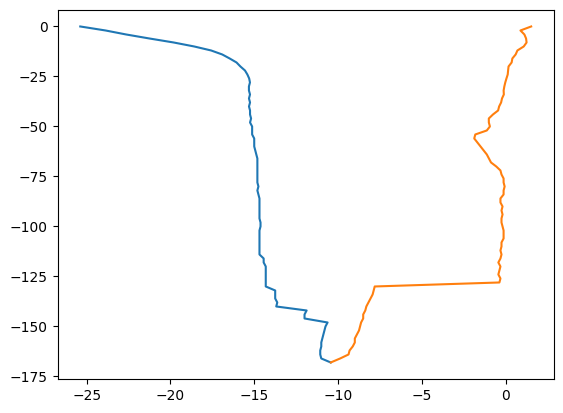

In [400]:
plt.plot(temps_rel_to_sfc.min(axis=0), sub_depths)
plt.plot(temps_rel_to_sfc.max(axis=0), sub_depths)

In [401]:
detrend_corr = np.ma.corrcoef(detrend_temps[:,0], detrend_temps[:,1:].T)[0][1:]


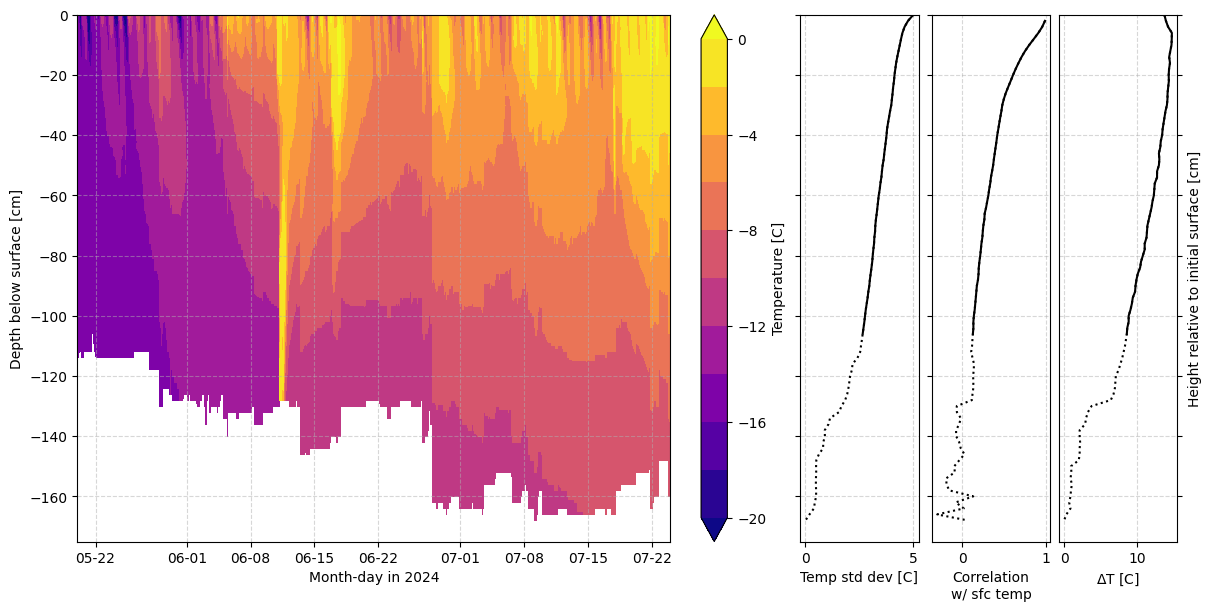

In [402]:
fig, axs = plt.subplots(1,4, figsize=(12,6), sharey=True, 
                        gridspec_kw=dict(width_ratios=[5,1,1,1]), constrained_layout=True)

cb = axs[0].contourf(season_data_solar['dates'], sub_depths, np.swapaxes(temps_rel_to_sfc,0,1), cmap='plasma',
                    levels=np.arange(-20,0.1,2), extend='both')
plt.colorbar(cb, label='Temperature [C]', ax=axs[0])

labels = ['Temp std dev [C]','Correlation\nw/ sfc temp','$\Delta$T [C]']
# for i, (ax, var) in enumerate(zip(axs.ravel()[1:], [temp_std_profile, temp_corrs, dT_dt_rel_to_sfc])):
for i, (ax, var) in enumerate(zip(axs.ravel()[1:], [temp_std_profile, detrend_corr, dT_dt_rel_to_sfc])):

    # print(var)
    if i==1:
        ax.plot(var, sub_depths[1:],ls=':', c='k')
        ax.plot(detrend_corr[~temp_std_full[1:].mask], sub_depths[1:][~temp_std_full[1:].mask], c='k')
    else:
        ax.plot(var, sub_depths, ls=':', c='k')
        ax.plot(var[~temp_std_full.mask], sub_depths[~temp_std_full.mask], c='k')

    ax.set_xlabel(labels[i])
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth below surface [cm]')
axs[0].xaxis.set_major_formatter(myFmt)
axs[0].set_xlabel('Month-day in 2024')

axs[-1].yaxis.set_label_position("right")
axs[-1].yaxis.tick_right()
axs[-1].set_ylabel('Height relative to initial surface [cm]')

axs[0].set_ylim(-175,0)
axs[0].grid(alpha=.5, ls='--')
plt.show()

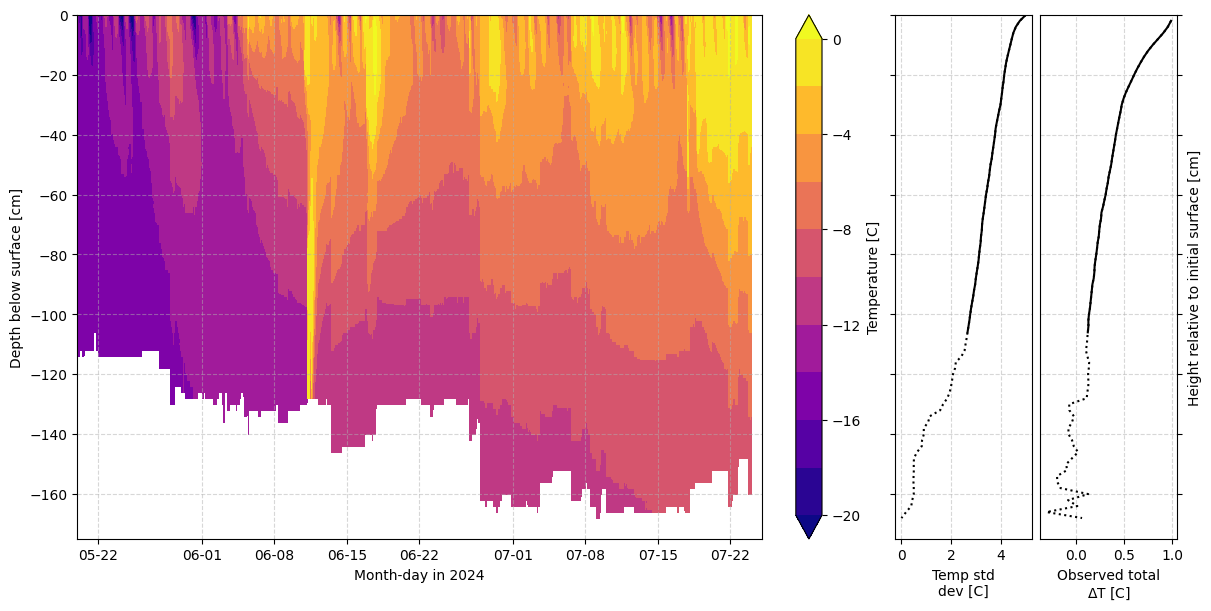

In [403]:
fig, axs = plt.subplots(1,3, figsize=(12,6), sharey=True, 
                        gridspec_kw=dict(width_ratios=[5,1,1]), constrained_layout=True)

cb = axs[0].contourf(season_data_solar['dates'], sub_depths, np.swapaxes(temps_rel_to_sfc,0,1), cmap='plasma',
                    levels=np.arange(-20,0.1,2), extend='both')
plt.colorbar(cb, label='Temperature [C]', ax=axs[0])

labels = ['Temp std\ndev [C]','Observed total\n$\Delta$T [C]']
# for i, (ax, var) in enumerate(zip(axs.ravel()[1:], [temp_std_profile, temp_corrs, dT_dt_rel_to_sfc])):
for i, (ax, var) in enumerate(zip(axs.ravel()[1:], [temp_std_profile, detrend_corr, dT_dt_rel_to_sfc])):

    # print(var)
    if i==1:
        ax.plot(var, sub_depths[1:],ls=':', c='k')
        ax.plot(detrend_corr[~temp_std_full[1:].mask], sub_depths[1:][~temp_std_full[1:].mask], c='k')
    else:
        ax.plot(var, sub_depths, ls=':', c='k')
        ax.plot(var[~temp_std_full.mask], sub_depths[~temp_std_full.mask], c='k')

    ax.set_xlabel(labels[i])
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth below surface [cm]')
axs[0].xaxis.set_major_formatter(myFmt)
axs[0].set_xlabel('Month-day in 2024')

axs[-1].yaxis.set_label_position("right")
axs[-1].yaxis.tick_right()
axs[-1].set_ylabel('Height relative to initial surface [cm]')

axs[0].set_xlim(dt(2024,5,20),dt(2024,7,25))
axs[0].set_ylim(-175,0)
axs[0].grid(alpha=.5, ls='--')
# plt.savefig(plrams_fpath+'SIMBA_corrected_temps-rel-to-sfc.png', dpi=300)
plt.show()

Is lag correlation just showing the dirunal cycle at the surface? 

KeyboardInterrupt: 

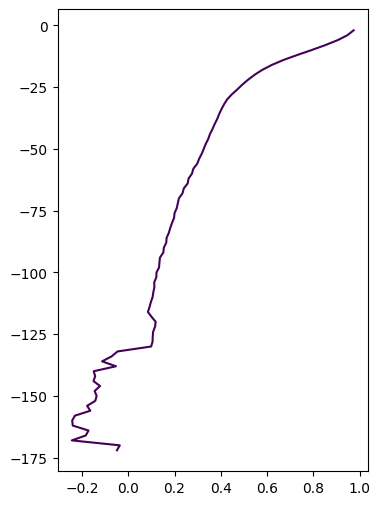

In [271]:
fig, ax = plt.subplots(1, figsize=(4,6))

max_lag = 3*24*4
for lag in range(0,max_lag+1,2):
    if lag==0:
        lagged_corrs = detrend_corr[np.newaxis,:]
        continue
    # print(lag)
    detrend_corr_lag = np.ma.corrcoef(detrend_temps[lag:,0], detrend_temps[:-lag,1:].T)[0][1:]

    lagged_corrs = np.ma.concatenate( (lagged_corrs, detrend_corr_lag[np.newaxis,:]), axis=0)
    
    col = plt.cm.viridis(lag/max_lag)

    plt.plot(detrend_corr_lag, sub_depths[1:], c=col)

plt.plot(detrend_corr[~temp_std_full[1:].mask], sub_depths[1:][~temp_std_full[1:].mask], c='k')

cmappable = ScalarMappable(norm=Normalize(0,1), cmap=plt.cm.viridis)

#colorbar from https://stackoverflow.com/questions/65618997/python-matplotlib-custom-colorbar-for-plotted-lines-with-manually-assigned-color
cbar = plt.colorbar(cmappable, ticks=np.arange(0, 2), label='Lag', ax=ax)
cbar.ax.set_yticklabels(['15 minutes','48 hours'])

plt.ylabel('Depth from surface [cm]')
plt.xlabel('Correlation w/ sfc temp')
plt.ylim(-118,0)
plt.xlim(-.2,1)
plt.grid(alpha=.5, ls='--')
# plt.savefig('Raven_temp-lag-corr_rel-to-sfc.png', dpi=250)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, figsize=(4,6), constrained_layout=True)

max_lag = 3*24*4
for lag in range(0,max_lag+1,6):
    if lag==0:
        lagged_corrs_sparse = detrend_corr[np.newaxis,:]
        continue
    # print(lag)
    detrend_corr_lag = np.ma.corrcoef(detrend_temps[lag:,0], detrend_temps[:-lag,1:].T)[0][1:]

    lagged_corrs_sparse = np.ma.concatenate( (lagged_corrs_sparse, detrend_corr_lag[np.newaxis,:]), axis=0)
    
    col = plt.cm.viridis(lag/max_lag)

    plt.plot(detrend_corr_lag, sub_depths[1:], c=col)

plt.plot(detrend_corr[~temp_std_full[1:].mask], sub_depths[1:][~temp_std_full[1:].mask], c='k')

cmappable = ScalarMappable(norm=Normalize(0,1), cmap=plt.cm.viridis)

#colorbar from https://stackoverflow.com/questions/65618997/python-matplotlib-custom-colorbar-for-plotted-lines-with-manually-assigned-color
cbar = plt.colorbar(cmappable, ticks=np.arange(0, 2), label='Lag', ax=ax)
cbar.ax.set_yticklabels(['15 min','72 hr'])

plt.ylabel('Depth from surface [cm]')
plt.xlabel('Correlation w/\nsfc temp')
plt.ylim(-118,0)
plt.xlim(-.25,1)
plt.grid(alpha=.5, ls='--')
# plt.savefig(plrams_fpath+'Raven_temp-lag-corr_rel-to-sfc_72hr-total_6hr-steps.png', dpi=250)
plt.show()

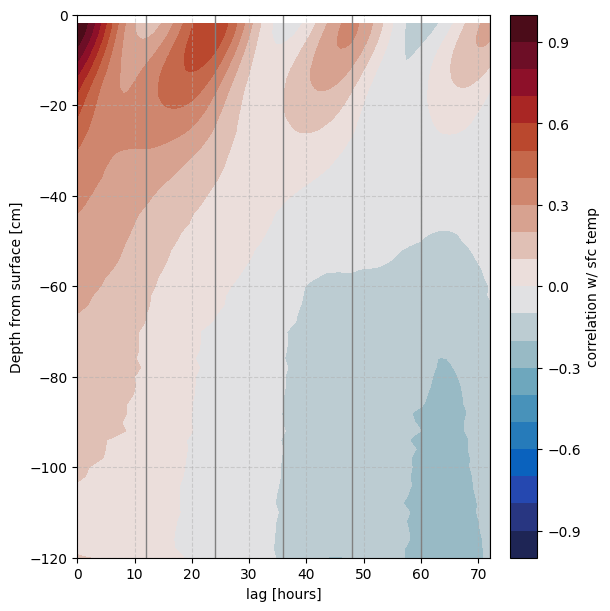

In [82]:
fig, ax = plt.subplots(1, figsize=(6,6), constrained_layout=True)
cb = plt.contourf(np.arange(0,max_lag+1,2)*15/60., sub_depths[1:], np.swapaxes(lagged_corrs,0,1),
                 levels=np.linspace(-1,1,21), cmap=cmocean.cm.balance)
plt.colorbar(cb, label='correlation w/ sfc temp')
plt.ylabel('Depth from surface [cm]')
plt.xlabel('lag [hours]')
plt.ylim(-120,0)
plt.grid(alpha=.5, ls='--')

for a in range(12,73,12):
    plt.axvline(x=a, c='gray', lw=1)
# plt.savefig('Raven_lagg-corrs_dpth-from-sfc_contour_72-hours.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_corrected_temp-correlations-rel-to-sfcT.png', dpi=300)

plt.show()


In [49]:
from numpy.fft import fft, ifft


In [85]:
def corr_np(data1, data2, a=0):
    mean1 = data1.mean(axis=a) 
    mean2 = data2.mean(axis=a)
    std1 = data1.std(axis=a)
    std2 = data2.std(axis=a)
    corr = ((data1*data2).mean(axis=a)-mean1*mean2)/(std1*std2)
    return corr

In [86]:
lag  = 2
# corr_at_depth = fft(detrend_temps, axis=1)
corr_at_depth = corr_np(detrend_temps[1:,:], detrend_temps[:-1,:])
print(corr_at_depth)

[0.9936240567221901 0.994646187429977 0.9957164133929975
 0.9964180983287325 0.9968060765279836 0.9969770512043061
 0.9971220073379827 0.9973042226026386 0.9974118237029709
 0.9974839803859287 0.9975539120045261 0.9974764634656458
 0.9974137169880344 0.9971544406502477 0.9966927507886498
 0.996164172690605 0.9955252955435921 0.9953772756382682
 0.9957474346895836 0.9962404094269516 0.9965027797537421
 0.9967249916562011 0.9969122883506385 0.9970770447063868
 0.9973014457434959 0.997429484785605 0.997587527521579 0.9976323760740884
 0.9978282119683402 0.9980074258668533 0.9981914074267729
 0.9982295077374466 0.9982368430332961 0.9982513849964443
 0.9981929270055545 0.9982630651744977 0.9982551839599794
 0.9982832590053482 0.9981660851257641 0.998038209664814
 0.9977781428158146 0.997469859941289 0.9971536352211232
 0.9966659957357107 0.9960804644152731 0.9958283282919898
 0.9961043763857186 0.9964820433511091 0.9968394971537924
 0.9970435971834307 0.9971259637952752 0.9972269179966597
 

In [87]:
# For Michael: lagged correlations at each depth

max_lag = 3*24*4
# max_lag = 4*4
step = 2
for lag in range(0,max_lag+1,step):
    if lag==0:
        continue

    detrend_corr_lag = corr_np(detrend_temps[lag:,:], detrend_temps[:-lag,:])
    if lag==step:
        lagged_corrs_at_depth = detrend_corr_lag[np.newaxis,:]
    else:
        lagged_corrs_at_depth = np.ma.concatenate( (lagged_corrs_at_depth, detrend_corr_lag[np.newaxis,:]), axis=0)
    


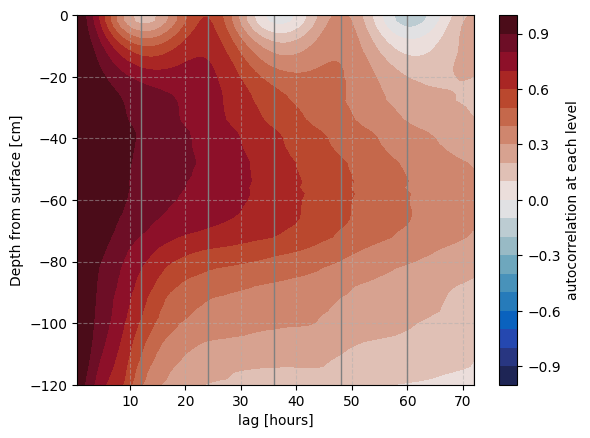

In [88]:
cb = plt.contourf(np.arange(0,max_lag+1,2)[1:]*15/60., sub_depths[:], np.swapaxes(lagged_corrs_at_depth,0,1),
                 levels=np.linspace(-1,1,21), cmap=cmocean.cm.balance)
plt.colorbar(cb, label='autocorrelation at each level')
plt.ylabel('Depth from surface [cm]')
plt.xlabel('lag [hours]')
plt.ylim(-120,0)
plt.grid(alpha=.5, ls='--')

for a in range(12,73,12):
    plt.axvline(x=a, c='gray', lw=1)
# plt.savefig('Raven_lagg-autocorrs_dpth-from-sfc_contour_72-hours.png', dpi=250)
plt.show()

Average diurnal cycles?

In [404]:
simba_hours = np.array([d.hour for d in season_data_solar['dates']])
simba_mins = np.array([d.minute for d in season_data_solar['dates']])

## time of day
simba_tod = simba_hours+simba_mins/60.

In [405]:
grads_rel_to_sfc =  np.gradient(temps_rel_to_sfc, sub_depths, axis=1)

In [406]:
daily_avgs = np.array([temps_rel_to_sfc[np.where(simba_tod==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])
daily_std = np.array([temps_rel_to_sfc[np.where(simba_tod==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])

daily_avgs_dTdz = np.array([grads_rel_to_sfc[np.where(simba_tod==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])


## these dates are somewhat arbitrary at the moment - should be more carefully chosen!
begin_idx = np.where(season_data_solar['dates']<dt(2024,6,9))[0]
daily_avgs_beginning = np.array([temps_rel_to_sfc[begin_idx,:][np.where(simba_tod[begin_idx]==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])
daily_std_beginning = np.array([temps_rel_to_sfc[begin_idx,:][np.where(simba_tod[begin_idx]==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])
daily_dTdz_beginning = np.array([grads_rel_to_sfc[begin_idx,:][np.where(simba_tod[begin_idx]==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])

end_idx = np.where(season_data_solar['dates']>dt(2024,7,1))[0]
daily_avgs_end = np.array([temps_rel_to_sfc[end_idx,:][np.where(simba_tod[end_idx]==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])
daily_std_end = np.array([temps_rel_to_sfc[end_idx,:][np.where(simba_tod[end_idx]==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])
daily_dTdz_end = np.array([grads_rel_to_sfc[end_idx,:][np.where(simba_tod[end_idx]==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])

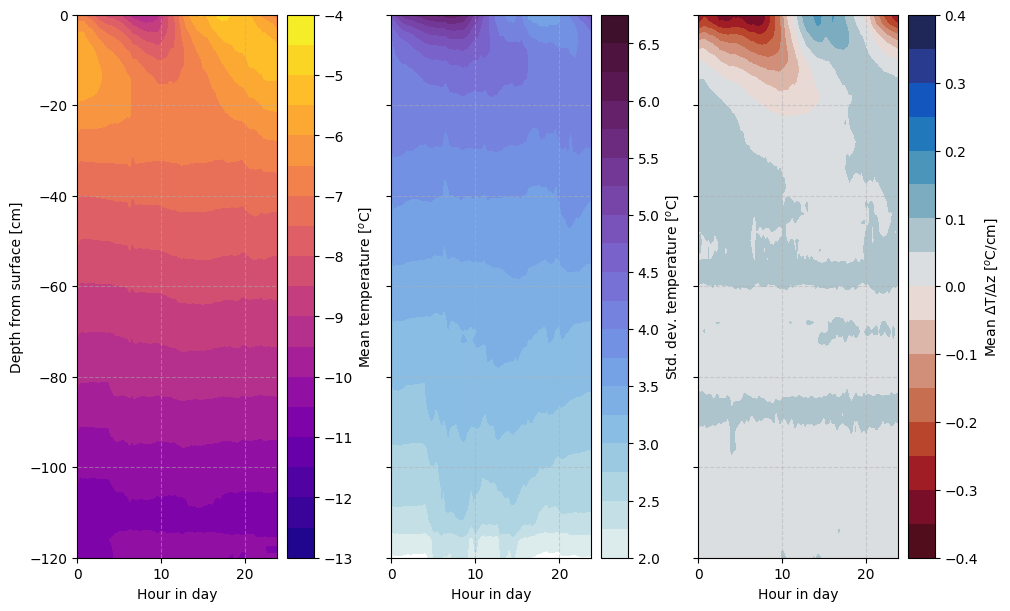

In [407]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]

for i, (ax, var) in enumerate(zip(axs.ravel(), [daily_avgs, daily_std, daily_avgs_dTdz])):
    cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
# plt.tight_layout()
plt.show()

/tmp/ipykernel_2874015/1771002205.py:10: UserWarning: The following kwargs were not used by contour: 'exend'
  cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i], exend='both')


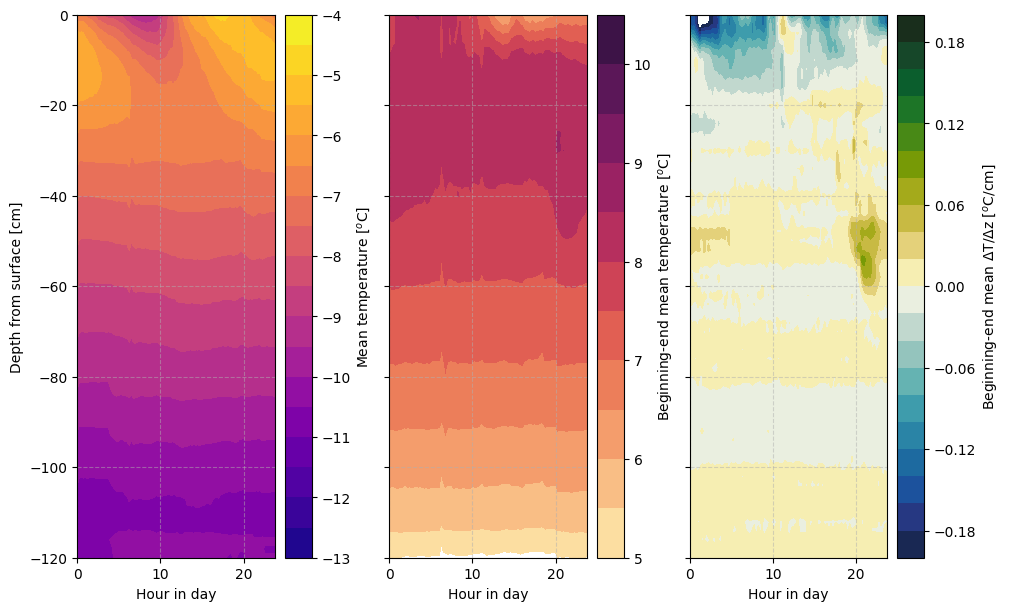

In [408]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Beginning-end mean temperature [$^o$C]', 'Beginning-end mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(5,11,.5), np.arange(-0.2,0.21,.02)]
cmaps = [plt.cm.plasma, cmocean.cm.matter, cmocean.cm.delta]
extends = [None, None, 'both']

for i, (ax, var) in enumerate(zip(axs.ravel(), [daily_avgs, daily_avgs_end-daily_avgs_beginning, daily_dTdz_end-daily_dTdz_beginning])):
    if i== 2:
        cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i], exend='both')
    else:
        cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])

    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
# plt.tight_layout()
plt.show()

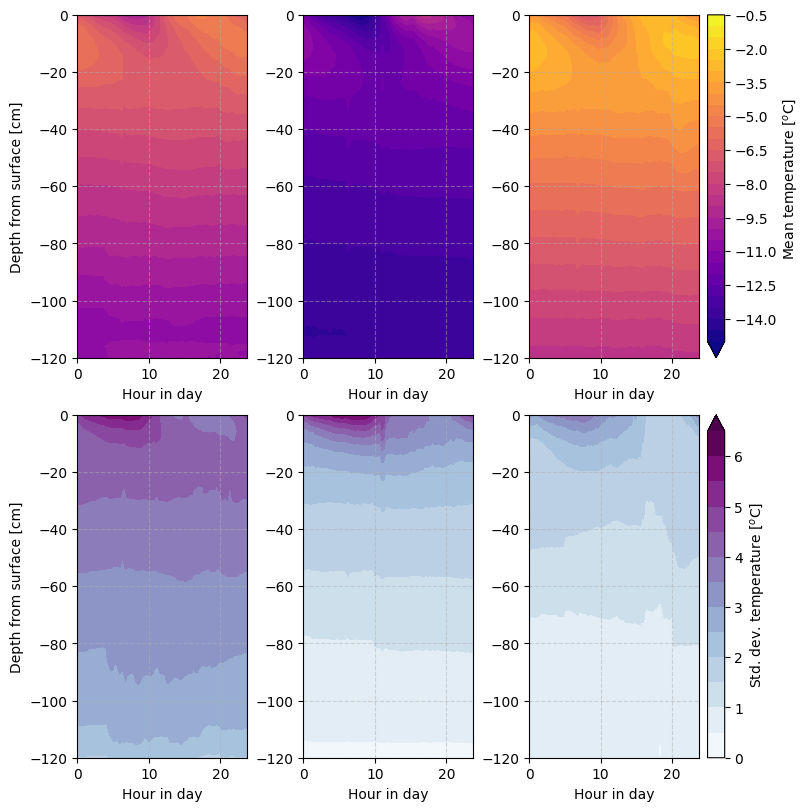

In [409]:
fig, axs = plt.subplots(2,3, figsize=(8,8), constrained_layout=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]']
levels = [np.arange(-15,0,.5), np.arange(0,7,.5)]
cmaps = [plt.cm.plasma, plt.cm.BuPu]
extends = ['min','max']

subtitles = ['Full season', 'Before June 9, 2024', 'After July 1, 2024']

all_data = [[daily_avgs, daily_avgs_beginning, daily_avgs_end], [daily_std, daily_std_beginning, daily_std_end]]

for i, dataset in enumerate(all_data):
    for j, var in enumerate(dataset):
    
        cb = axs[i][j].contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], extend=extends[i], cmap=cmaps[i])
        if j==2:
            plt.colorbar(cb, label=cbar_labels[i], ax=axs[i][j])
    
        axs[i][j].set_ylim(-120,0)
        
        axs[i][j].set_xlabel('Hour in day')
        axs[i][j].grid(alpha=.5, ls='--')

    axs[i][0].set_ylabel('Depth from surface [cm]')
# plt.tight_layout()
plt.show()

#### comparing uncorrected mean, std dev, and dT/dz

In [410]:
unc_idx = np.where( (season_data_unc['dates']>=season_data_solar['dates'][0])&(season_data_unc['dates']<=season_data_solar['dates'][-1]) )[0]

In [411]:
unc_temps = season_data_unc['temperature'][unc_idx,:]

In [412]:
temporary_temp_unc = np.ma.masked_where(depths_rel_to_sfc>0, unc_temps)# temporary temperature

temps_rel_to_sfc_unc = []

m = 100 # size of 

for i in range(temporary_temp_unc.shape[0]):
    temp_i = temporary_temp_unc[i,:-1]
    sub_t = temp_i[~temp_i.mask]

    sub_t_filled = np.ma.concatenate( (sub_t, np.full(int(m-sub_t.count()), -999 )) )
    temps_rel_to_sfc_unc.append(sub_t_filled)
    
temps_rel_to_sfc_unc = np.ma.masked_equal(temps_rel_to_sfc_unc, -999)

In [413]:
grads_rel_to_sfc_unc =  np.gradient(temps_rel_to_sfc_unc,sub_depths,  axis=1)

In [414]:
daily_avgs_unc = np.array([temps_rel_to_sfc_unc[np.where(simba_tod==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])
daily_std_unc = np.array([temps_rel_to_sfc_unc[np.where(simba_tod==t)[0],:].std(axis=0) for t in np.unique(simba_tod)])

daily_avgs_dTdz_unc = np.array([grads_rel_to_sfc_unc[np.where(simba_tod==t)[0],:].mean(axis=0) for t in np.unique(simba_tod)])

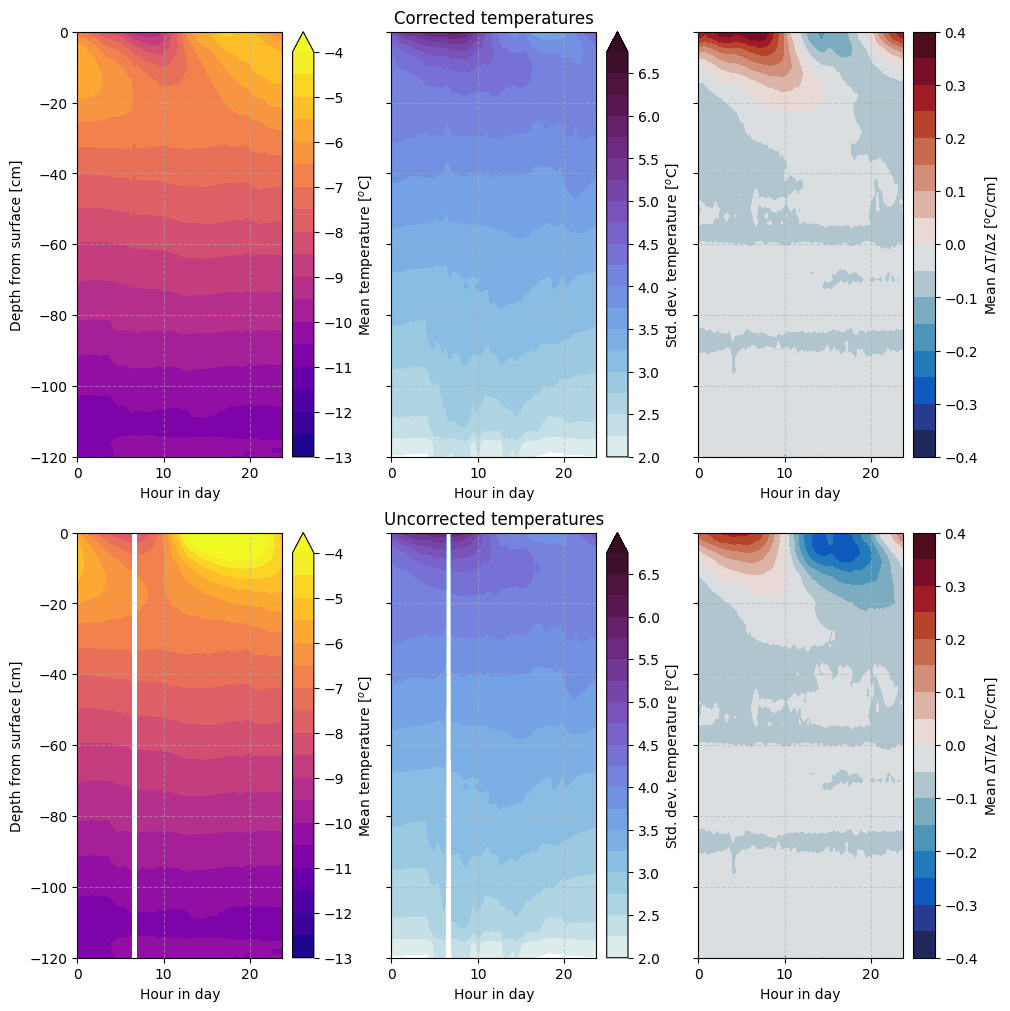

In [415]:
fig, axs = plt.subplots(2,3, figsize=(10,10), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance]

suptitles = ['Corrected temperatures', 'Uncorrected temperatures']

for j, datasets in enumerate([[daily_avgs, daily_std, daily_avgs_dTdz*-1.],[daily_avgs_unc, daily_std_unc, daily_avgs_dTdz_unc*-1.]]):

    for i, var in enumerate(datasets):
        if i<2:
            cb = axs[j][i].contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i], extend='max')
        else:
            cb = axs[j][i].contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    
        plt.colorbar(cb, label=cbar_labels[i], ax=axs[j][i])
    
        axs[j][i].set_ylim(-120,0)
        
        axs[j][i].set_xlabel('Hour in day')
        axs[j][i].grid(alpha=.5, ls='--')
    axs[j][1].set_title(suptitles[j])
    axs[j][0].set_ylabel('Depth from surface [cm]')


# plt.tight_layout()
plt.show()

-3.0413091549450897


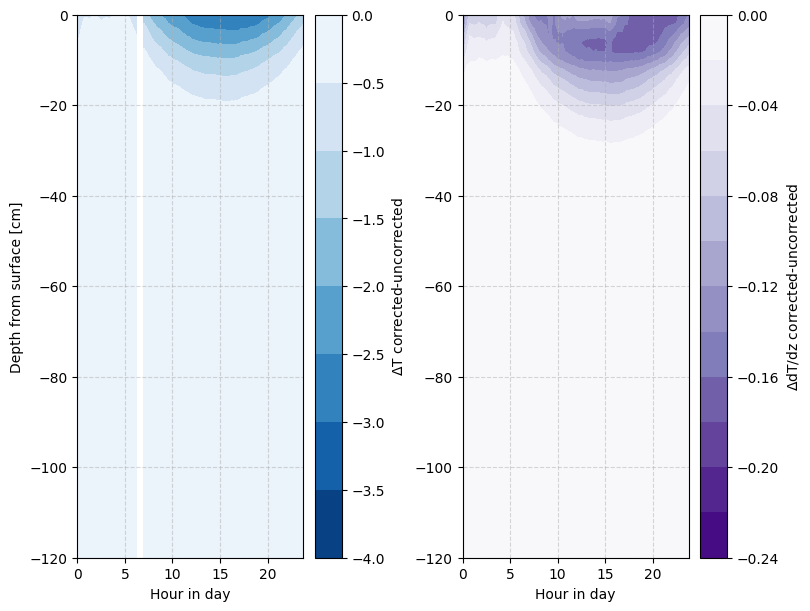

In [416]:
avg_t_diff = np.ma.masked_invalid(daily_avgs - daily_avgs_unc)

avg_dTdz_diff = daily_avgs_dTdz - daily_avgs_dTdz_unc

print(avg_t_diff.min())

fig, axs = plt.subplots(1,2, figsize=(8,6), constrained_layout=True)

cb = axs[0].contourf(np.unique(simba_tod), sub_depths, np.swapaxes(avg_t_diff,0,1), levels=np.arange(-4,0.1,0.5), cmap=plt.cm.Blues_r)
plt.colorbar(cb, label='$\Delta$T corrected-uncorrected', ax=axs[0])

cb = axs[1].contourf(np.unique(simba_tod), sub_depths, np.swapaxes(avg_dTdz_diff,0,1), levels=np.arange(-.24,.01,0.02), cmap=plt.cm.Purples_r)
plt.colorbar(cb, label='$\Delta$dT/dz corrected-uncorrected', ax=axs[1])

for ax in axs.ravel():
    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')
# axs[j][1].set_title(suptitles[j])
axs[0].set_ylabel('Depth from surface [cm]')
plt.show()

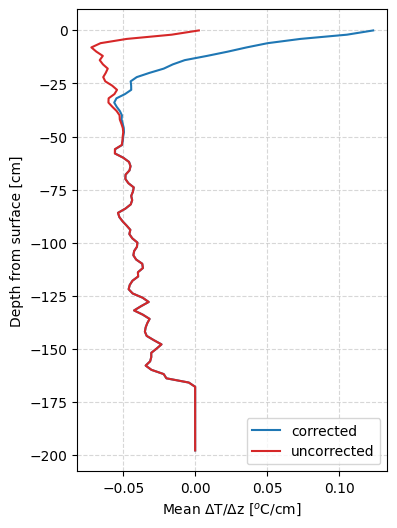

In [417]:
plt.figure(figsize=(4,6))

plt.plot(-1.*daily_avgs_dTdz.mean(axis=0), sub_depths, label='corrected')
plt.plot(-1.*daily_avgs_dTdz_unc.mean(axis=0), sub_depths, label='uncorrected', c='tab:red')
plt.grid(alpha=.5, ls='--')
plt.xlabel('Mean $\Delta$T/$\Delta$z [$^o$C/cm]')
plt.ylabel('Depth from surface [cm]')
plt.legend(loc='best')

plt.show()

#### Melt vs nonmelt days?

In [418]:
# simba_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in season_data['dates']])
gpr_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in gpr_dates])

simba_solar_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in season_data_solar['dates']])

f_gpr = interpolate.interp1d(gpr_seconds, gpr_melt, fill_value=-999, bounds_error=False)
gpr_simba_dates = f_gpr(simba_solar_seconds)
gpr_simba_dates = np.ma.masked_equal(gpr_simba_dates, -999)

In [419]:
melty_dates = np.ma.masked_where(gpr_simba_dates<0.8, season_data_solar['dates'])
melty_day_mn = np.unique([' '.join((str(d.day), str(d.month))) for d in melty_dates[~melty_dates.mask]])
all_day_mn = np.asarray([' '.join((str(d.day), str(d.month))) for d in season_data_solar['dates']])


In [420]:
## inefficient but whatever
simba_melty_idx = np.zeros(season_data_solar['dates'].shape)

for md in melty_day_mn:
    # print(md, np.where(all_day_mn==md))
    
    simba_melty_idx[np.where(all_day_mn==md)] = 1

# print(np.unique(all_day_mn[np.where(simba_melty_idx==1)]))

In [421]:
print('# of melty days: ', len(melty_day_mn))
print('# of non-melty days: ', len(np.unique(all_day_mn[np.where(simba_melty_idx==0)[0]]))),
print('# of all days: ', len(np.unique(all_day_mn)))

# of melty days:  19
# of non-melty days:  46
# of all days:  65


In [422]:
grads_rel_to_sfc_dry = grads_rel_to_sfc[np.where(simba_melty_idx==0)[0],:]
dry_simba_tod = simba_tod[np.where(simba_melty_idx==0)[0]]
daily_avgs_dTdz_dry = np.array([grads_rel_to_sfc_dry[np.where(dry_simba_tod==t)[0],:].mean(axis=0) for t in np.unique(dry_simba_tod)])

grads_rel_to_sfc_melty = grads_rel_to_sfc[np.where(simba_melty_idx==1)[0],:]
melty_simba_tod = simba_tod[np.where(simba_melty_idx==1)[0]]
daily_avgs_dTdz_melty = np.array([grads_rel_to_sfc_melty[np.where(melty_simba_tod==t)[0],:].mean(axis=0) for t in np.unique(melty_simba_tod)])

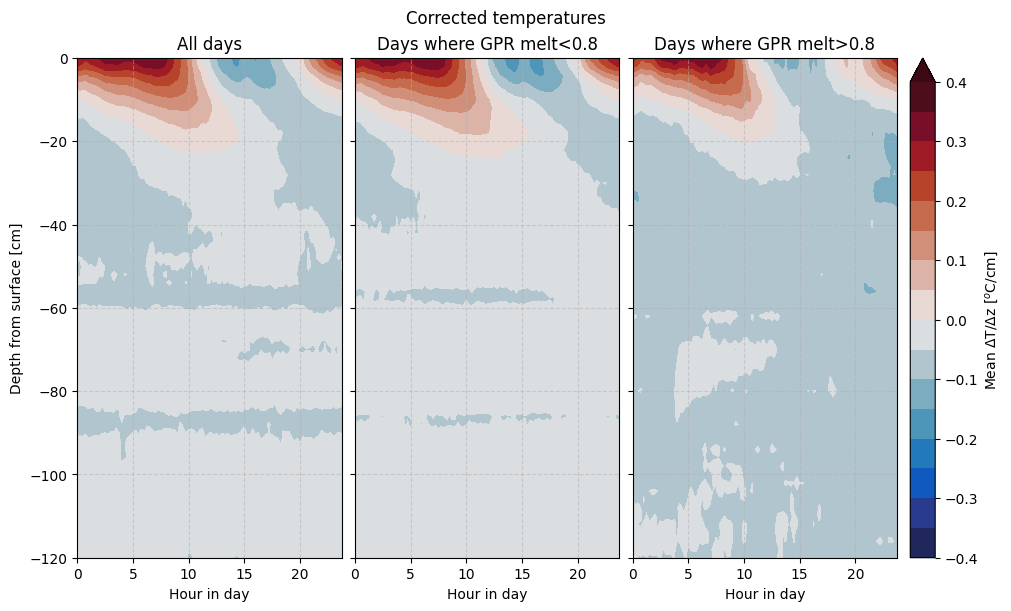

In [423]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']


for i, (ax, var) in enumerate(zip(axs.ravel(), [daily_avgs_dTdz, daily_avgs_dTdz_dry, daily_avgs_dTdz_melty])):
    cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                     cmap=cmocean.cm.balance, extend='max')
    

    ax.set_ylim(-120,0)
    ax.set_title(subtitles[i])
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[-1])

axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle('Corrected temperatures')
# plt.tight_layout()
plt.show()

In [424]:
grads_rel_to_sfc_dry_unc = grads_rel_to_sfc_unc[np.where(simba_melty_idx==0)[0],:]
dry_simba_tod = simba_tod[np.where(simba_melty_idx==0)[0]]
daily_avgs_dTdz_dry_unc = np.array([grads_rel_to_sfc_dry_unc[np.where(dry_simba_tod==t)[0],:].mean(axis=0) for t in np.unique(dry_simba_tod)])

grads_rel_to_sfc_melty_unc = grads_rel_to_sfc_unc[np.where(simba_melty_idx==1)[0],:]
melty_simba_tod = simba_tod[np.where(simba_melty_idx==1)[0]]
daily_avgs_dTdz_melty_unc = np.array([grads_rel_to_sfc_melty_unc[np.where(melty_simba_tod==t)[0],:].mean(axis=0) for t in np.unique(melty_simba_tod)])

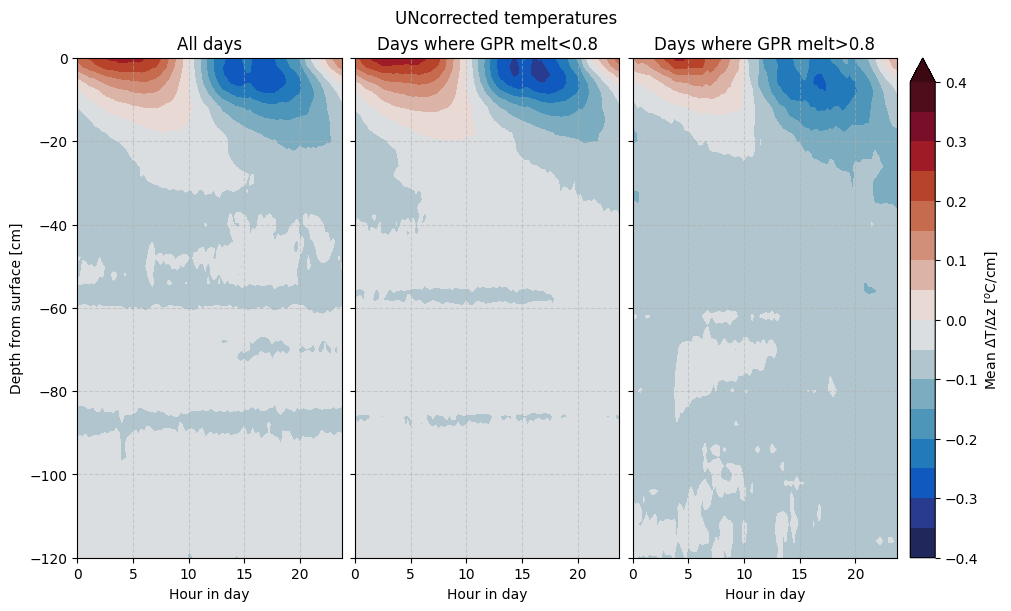

In [425]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']


for i, (ax, var) in enumerate(zip(axs.ravel(), [daily_avgs_dTdz_unc, daily_avgs_dTdz_dry_unc, daily_avgs_dTdz_melty_unc])):
    cb = ax.contourf(np.unique(simba_tod), sub_depths, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                     cmap=cmocean.cm.balance, extend='max')
    

    ax.set_ylim(-120,0)
    ax.set_title(subtitles[i])
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[-1])

axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle('UNcorrected temperatures')
# plt.tight_layout()
plt.show()

## Relative to SIMBA not surface

In [426]:
simba_temperature = np.ma.masked_invalid(season_data_solar['temperature'].copy())
dT_dt_rel_to_simba = simba_temperature[1:,:] - simba_temperature[:-1,:]
dT_dt_rel_to_simba = dT_dt_rel_to_simba.sum(axis=0)

In [427]:
simba_temp_masked = np.ma.masked_outside(np.ma.masked_invalid(season_data_solar['temperature']), -50,5)
simba_dTdt = simba_temp_masked[1:,:] - simba_temp_masked[:-1,:]

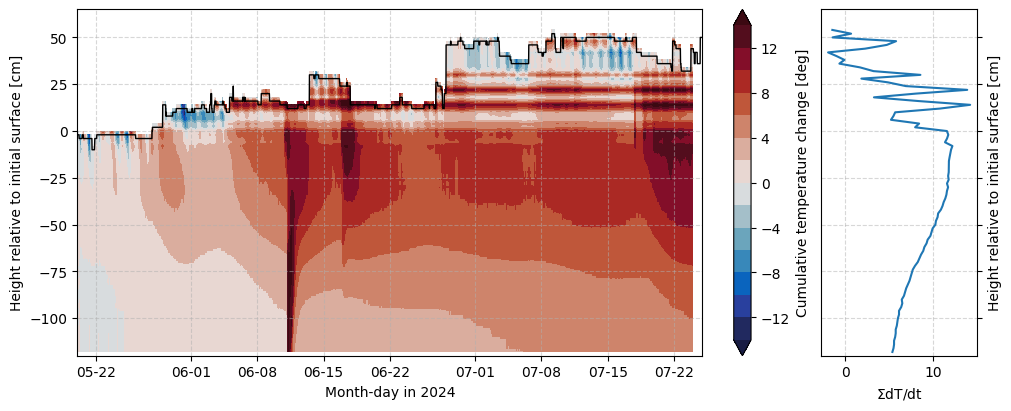

In [428]:
fig, axs =plt.subplots(1,2, figsize=(10,4), gridspec_kw=dict(width_ratios=[4,1]), constrained_layout=True, sharey=True)

cumul_temp = np.ma.cumsum(simba_dTdt, axis=0)

cb = axs[0].contourf(season_data_solar['dates'][:-1], season_data_solar['height'], np.swapaxes(cumul_temp,0,1),
                    cmap=cmocean.cm.balance, levels=np.arange(-14,14.1,2.), extend='both')
axs[0].plot(season_data['dates'], simba_sfc, c='k', lw=1)

plt.colorbar(cb, label='Cumulative temperature change [deg]', ax=axs[0])
axs[0].set_ylim(-120,65)
axs[0].set_xlim(dt(2024,5,20), dt(2024,7,25))

axs[0].xaxis.set_major_formatter(myFmt)
axs[0].set_xlabel('Month-day in 2024')
axs[0].set_ylabel('Height relative to initial surface [cm]')
axs[0].grid(alpha=.5, ls='--')


axs[1].plot(dT_dt_rel_to_simba, season_data_solar['height'], c='tab:blue')
axs[1].set_xlabel('$\Sigma$dT/dt')
axs[1].grid(alpha=.5, ls='--')

axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()
axs[1].set_ylabel('Height relative to initial surface [cm]')

# axs[1].set_ylabel('Height relative to initial surface [cm]')

plt.show()


Temperature gradients:

In [429]:
temp_vert_grad = np.gradient(simba_temp_masked, season_data_solar['height'], axis=1)

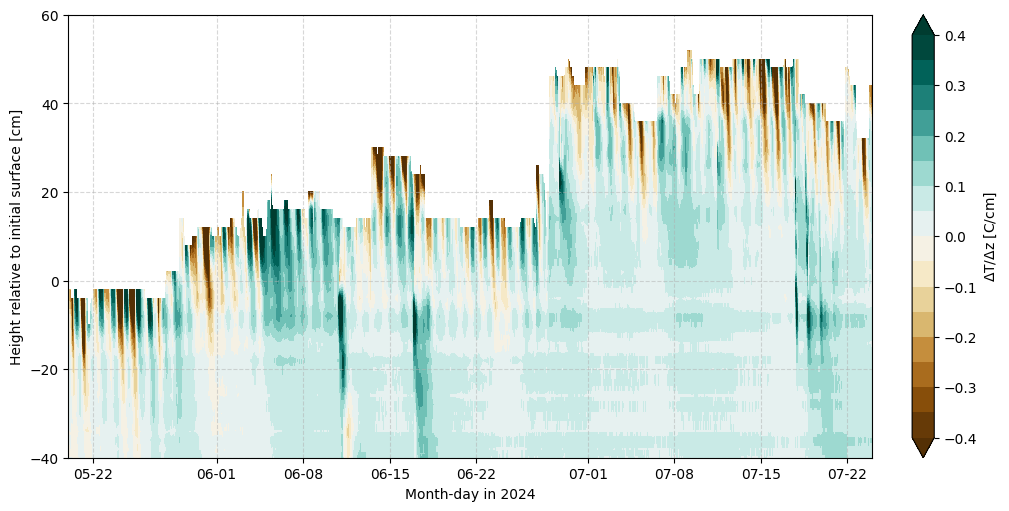

In [430]:
fig, ax = plt.subplots(1, figsize=(10,5), constrained_layout=True)

cb = ax.contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(temp_vert_grad,0,1),
                cmap=plt.cm.BrBG, levels=np.arange(-.4,.41,.05), extend='both')
plt.colorbar(cb, label='$\Delta$T/$\Delta$z [C/cm]')

ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.set_ylabel('Height relative to initial surface [cm]')
ax.grid(alpha=.5, ls='--')
# ax.set_ylim(-120,60)
ax.set_ylim(-40,60)

plt.show()

### starting to look at comparisons of melt events

In [431]:
asfs_data_lev2['net_lw'] = asfs_data_lev2['down_long_hemisp']-asfs_data_lev2['up_long_hemisp']
asfs_data_lev2['net_sw'] = asfs_data_lev2['down_short_hemisp']-asfs_data_lev2['up_short_hemisp']
asfs_data_lev2['net_rad'] = asfs_data_lev2['net_lw']+asfs_data_lev2['net_sw']

In [432]:
asfs_data_lev2['T2m_Tskin'] = asfs_data_lev2['temp']-(asfs_data_lev2['skin_temp']-273.15)

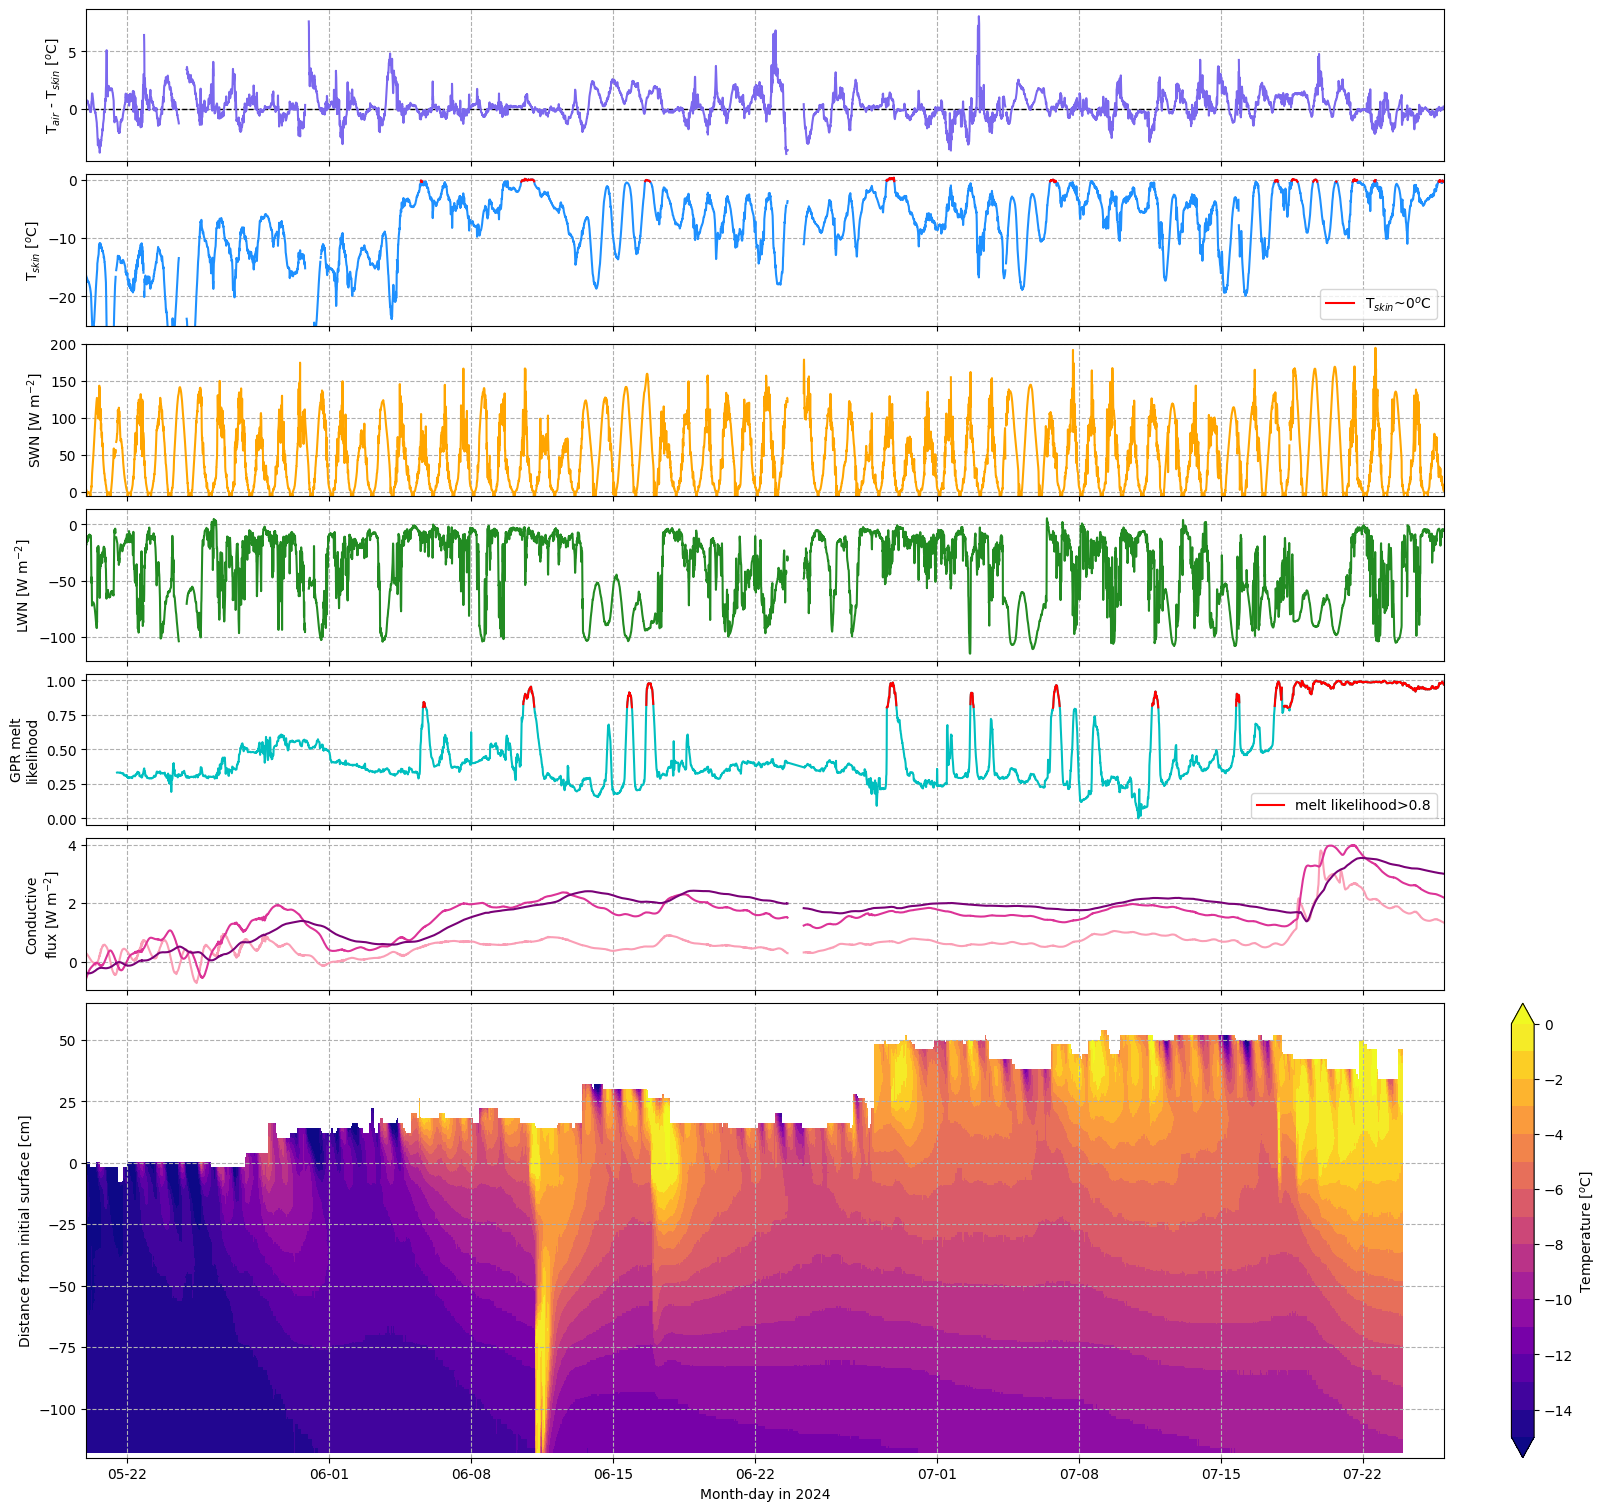

In [433]:
fig, axs = plt.subplots(7, figsize=(16,15), constrained_layout=True, 
                        sharex=True, gridspec_kw=dict(height_ratios=[1,1,1,1,1,1,3]))


for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--')

axs[1].plot(asfs_data_lev2['dates'], asfs_data_lev2['skin_temp']-273.15, c='dodgerblue')
axs[1].plot(asfs_data_lev2['dates'], np.ma.masked_less(asfs_data_lev2['skin_temp']-273.15, -0.32), c='r', label='T$_{skin}$~0$^o$C')
axs[1].set_ylabel('T$_{skin}$ [$^o$C]')

axs[0].axhline(y=0, c='k', ls='--', lw=1)
axs[0].plot(asfs_data_lev2['dates'], asfs_data_lev2['temp']-(asfs_data_lev2['skin_temp']-273.15), c='mediumslateblue')
axs[0].set_ylabel('T$_{air}$ - T$_{skin}$ [$^o$C]')

axs[2].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_short_hemisp']-asfs_data_lev2['up_short_hemisp'], c='orange')
axs[2].set_ylabel('SWN [W m$^{-2}$]')

axs[1].set_ylim(-25,1)


# axs[1].set_xlim(dt(2024,6,8),dt(2024,6,22))
axs[1].set_xlim(dt(2024,5,20),dt(2024,7,26))

axs[3].plot(asfs_data_lev2['dates'], asfs_data_lev2['down_long_hemisp']-asfs_data_lev2['up_long_hemisp'], c='forestgreen')
axs[3].set_ylabel('LWN [W m$^{-2}$]')

axs[4].plot(gpr_dates, gpr_melt, c='c')
axs[4].plot(gpr_dates, np.ma.masked_less(gpr_melt,.8), c='r', label='melt likelihood>0.8')
axs[4].set_ylabel('GPR melt\nlikelihood')

for fp, c in zip(['A','B','C'],['#FA9EB5','#DC3397','#790177']):
    axs[5].plot(asfs_data_lev2['dates'], asfs_data_lev2['subsurface_heat_flux_'+fp], c=c)
axs[5].set_ylabel('Conductive\nflux [W m$^{-2}$]')


# axs[-1].plot(plt_times, 100.*rnd_sfc-32, color='gray')
# axs[-1].plot(plt_times, 100*rnd_sfc, c='k')
# axs[-1].plot(asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], c='c')
# axs[-1].plot(season_data['dates'], simba_sfc, label='SIMBA algorithm')

cb = axs[-1].contourf(season_data_solar['dates'], season_data_solar['height'], np.swapaxes(season_data_solar['temperature'],0,1),
                cmap=plt.cm.plasma, levels=np.arange(-15,0.5,1), extend='both')
# axs[1].contour(simba_dates, simba_depths, np.swapaxes(corrected_temps_new,0,1),
#                 levels=[0], extend='both')
plt.colorbar(cb, ax=axs[-1], label='Temperature [$^o$C]')

axs[-1].set_ylim(-120,65)
axs[-1].set_ylabel('Distance from initial surface [cm]')

# axs[-1].plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser')
# axs[-1].plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger')

# for ogre in ['rav2_origin','rav3_west']:
#     axs[-1].plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., label='OGRE '+ogre.split('_')[-1])

for i in [1,4]:
    axs[i].legend(loc='lower right')

axs[2].set_ylim(-5,200)

axs[-1].xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')

# plt.savefig('Raven_stacked-timeseries_may20-jul26_poster.png', dpi=350)

plt.show()

In [434]:
tksin_melt_idx = np.ma.where(((asfs_data_lev2['skin_temp']-273.15)>=-0.32)&(asfs_data_lev2['dates']<datetime.datetime(2024,7,26)))[0]

sleigh_days = np.array([sleigh_date.day for sleigh_date in asfs_data_lev2['dates']])
sleigh_months = np.array([sleigh_date.month for sleigh_date in asfs_data_lev2['dates']])
sleigh_hours = np.array([sleigh_date.hour for sleigh_date in asfs_data_lev2['dates']])

for item in asfs_data_lev2['dates'][tksin_melt_idx]:
    print(item)

2024-06-05 12:30:00
2024-06-05 12:40:00
2024-06-05 13:20:00
2024-06-05 13:30:00
2024-06-05 13:40:00
2024-06-05 18:20:00
2024-06-09 15:40:00
2024-06-09 16:50:00
2024-06-09 19:00:00
2024-06-10 11:30:00
2024-06-10 11:40:00
2024-06-10 11:50:00
2024-06-10 12:00:00
2024-06-10 12:10:00
2024-06-10 12:20:00
2024-06-10 12:30:00
2024-06-10 12:40:00
2024-06-10 12:50:00
2024-06-10 13:00:00
2024-06-10 13:10:00
2024-06-10 13:20:00
2024-06-10 13:30:00
2024-06-10 13:40:00
2024-06-10 13:50:00
2024-06-10 14:00:00
2024-06-10 14:10:00
2024-06-10 14:20:00
2024-06-10 14:30:00
2024-06-10 14:40:00
2024-06-10 14:50:00
2024-06-10 15:00:00
2024-06-10 15:10:00
2024-06-10 15:20:00
2024-06-10 15:30:00
2024-06-10 15:40:00
2024-06-10 15:50:00
2024-06-10 16:00:00
2024-06-10 16:10:00
2024-06-10 16:20:00
2024-06-10 16:30:00
2024-06-10 16:40:00
2024-06-10 16:50:00
2024-06-10 17:00:00
2024-06-10 17:10:00
2024-06-10 17:20:00
2024-06-10 17:30:00
2024-06-10 17:40:00
2024-06-10 17:50:00
2024-06-10 18:00:00
2024-06-10 18:10:00


Start with one example before trying to automate to all the melt cases

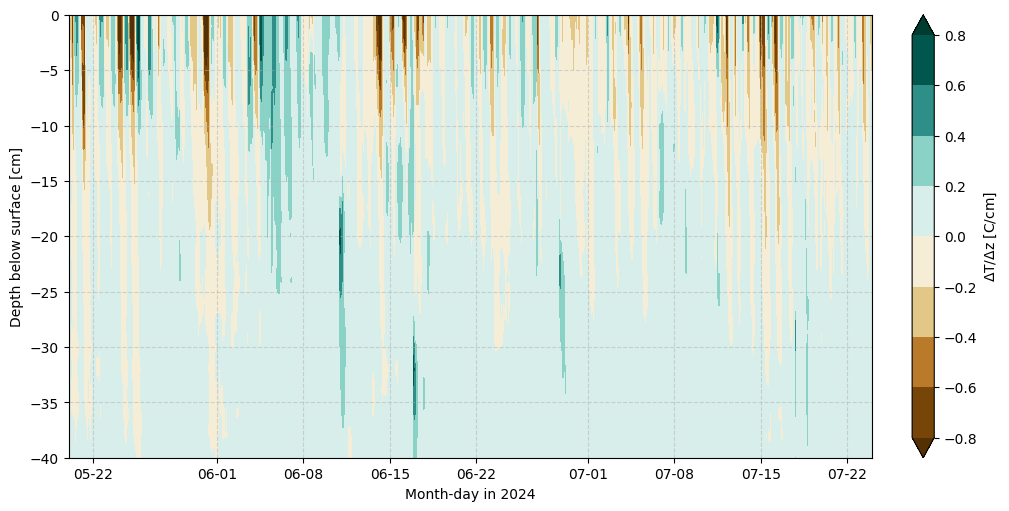

In [435]:
fig, ax = plt.subplots(1, figsize=(10,5), constrained_layout=True)

cb = ax.contourf(season_data_solar['dates'], sub_depths, np.swapaxes(grads_rel_to_sfc,0,1),
                cmap=plt.cm.BrBG, levels=np.arange(-.8,.81,.2), extend='both')
plt.colorbar(cb, label='$\Delta$T/$\Delta$z [C/cm]')

ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.set_ylabel('Depth below surface [cm]')
ax.grid(alpha=.5, ls='--')
# ax.set_ylim(-170,0)
ax.set_ylim(-40,0)
plt.show()

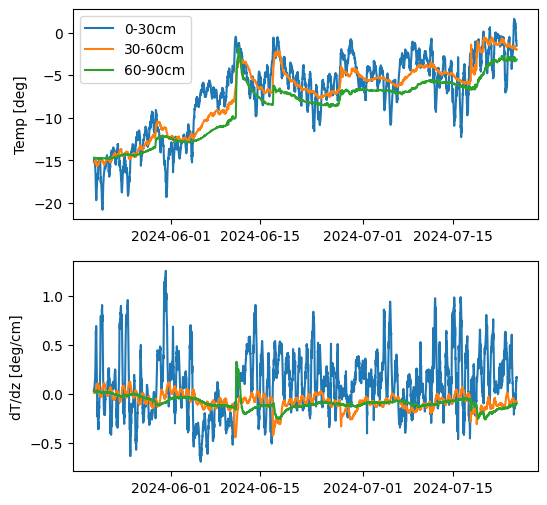

In [265]:
## temperautre in "responsive layer" and further down

temp_upper_30 = temps_rel_to_sfc[:,np.where(sub_depths>=-30)[0]].mean(axis=1)
temp_mid_30_60 = temps_rel_to_sfc[:,np.where((sub_depths<-30)&(sub_depths>=-60))[0]].mean(axis=1)
temp_mid_60_90 = temps_rel_to_sfc[:,np.where((sub_depths<-60)&(sub_depths>=-90))[0]].mean(axis=1)

grad_upper_30 = grads_rel_to_sfc[:,np.where(sub_depths>=-30)[0]].mean(axis=1)
grad_mid_30_60 = grads_rel_to_sfc[:,np.where((sub_depths<-30)&(sub_depths>=-60))[0]].mean(axis=1)
grad_mid_60_90 = grads_rel_to_sfc[:,np.where((sub_depths<-60)&(sub_depths>=-90))[0]].mean(axis=1)

fig, axs = plt.subplots(2, figsize=(6,6))
axs[0].plot(season_data_solar['dates'], temp_upper_30, label='0-30cm')
axs[0].plot(season_data_solar['dates'], temp_mid_30_60, label='30-60cm')
axs[0].plot(season_data_solar['dates'], temp_mid_60_90, label='60-90cm')

axs[0].set_ylabel('Temp [deg]')
axs[0].legend(loc='best')


axs[1].plot(season_data_solar['dates'], grad_upper_30, label='0-30cm')
axs[1].plot(season_data_solar['dates'], grad_mid_30_60, label='30-60cm')
axs[1].plot(season_data_solar['dates'], grad_mid_60_90, label='60-90cm')

axs[1].set_ylabel('dT/dz [deg/cm]')

plt.show()
# season_data_solar['dates'], sub_depths, np.swapaxes(

In [294]:
sleigh_dates = asfs_data_lev2['dates']

In [295]:
## local time is offset by two hours so 12 should be shifted?
big_melt_noon = datetime.datetime(2024,7,16,12)
other_melt_noon = datetime.datetime(2024,6,9,12)

# other_melt_noon = datetime.datetime(2024,6,28,12)
# other_melt_noon = datetime.datetime(2024,7,6,12) ## july 6 might have had three days in a row of melt, but GPR doesn't show continuous melt

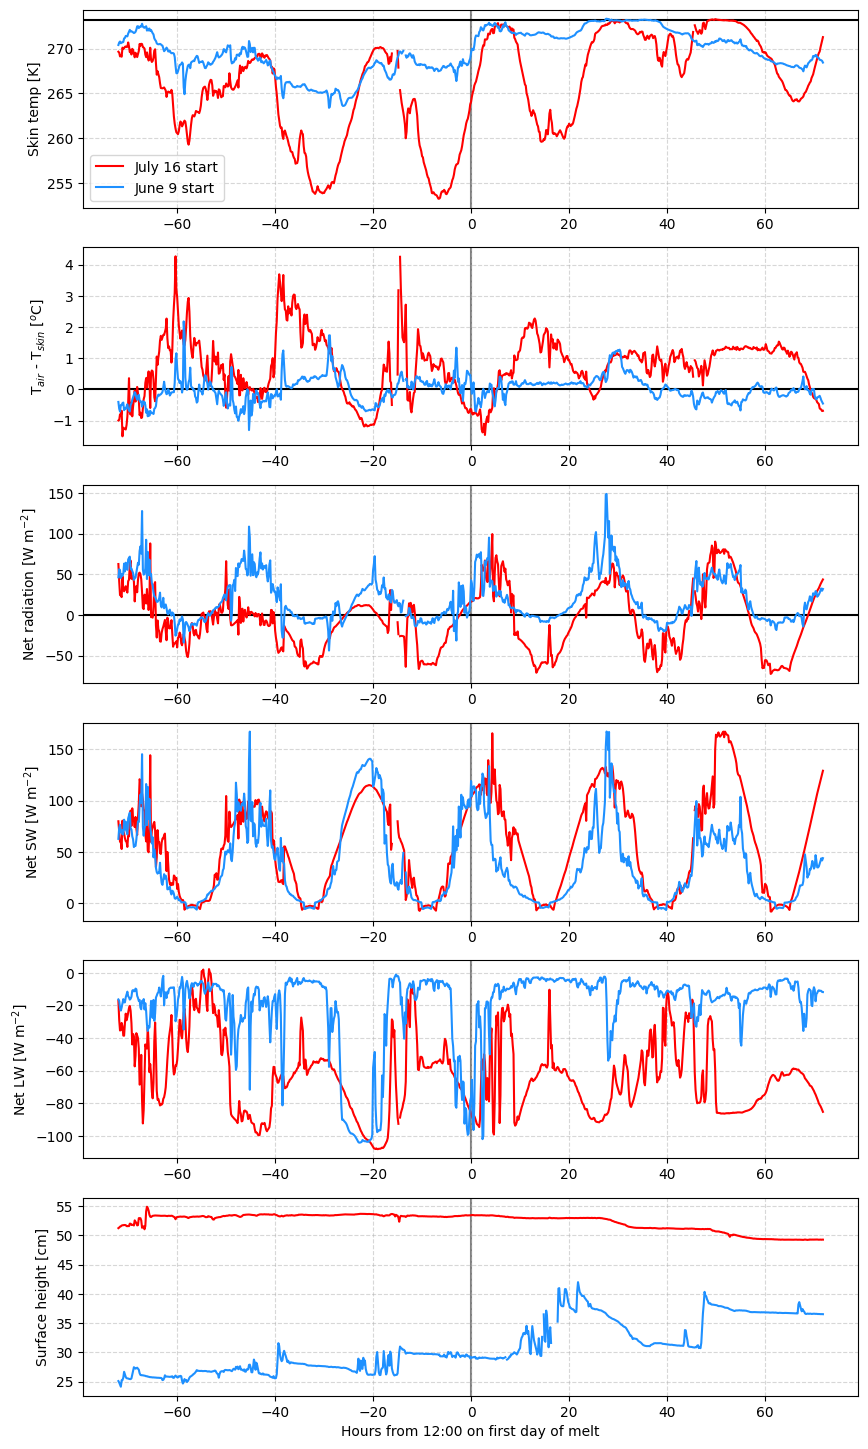

In [296]:
fig, axs = plt.subplots(6, figsize=(10,18))

labels = ['July 16 start','June 9 start']
# labels = ['July 17 start','July 6 start']
# labels = ['July 17 start','June 28 start']

colors = ['r', 'dodgerblue']
axs[0].axhline(y=273.15,c='k')
axs[1].axhline(y=0,c='k')
axs[2].axhline(y=0,c='k')


melt_length = 24*3

sleight_vars = ['skin_temp','T2m_Tskin','net_rad','net_sw','net_lw','snow_depth']

for i, melt_period in enumerate([big_melt_noon, other_melt_noon]):
    melt_period_idx = np.where((sleigh_dates>=melt_period-datetime.timedelta(hours=72))&(sleigh_dates<melt_period+datetime.timedelta(hours=melt_length)))[0]

    hours_since = [(d-melt_period).total_seconds() / 3600. for d in sleight_dates[melt_period_idx]]

    for ax, var in zip(axs.ravel(),sleight_vars):
        ax.plot(hours_since, (asfs_data_lev2[var])[melt_period_idx], label=labels[i],  c=colors[i])

    simba_period_idx = np.where((season_data_solar['dates']>=melt_period-datetime.timedelta(hours=72))&(season_data_solar['dates']<melt_period+datetime.timedelta(hours=melt_length)))[0]
    simba_hours_since = [(d-melt_period).total_seconds() / 3600. for d in season_data_solar['dates'][simba_period_idx]]


ylabels = ['Skin temp [K]','T$_{air}$ - T$_{skin}$ [$^o$C]', 'Net radiation [W m$^{-2}$]',
           'Net SW [W m$^{-2}$]', 'Net LW [W m$^{-2}$]', 'Surface height [cm]']
for ax, yl in zip(axs.ravel(),ylabels):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(yl)
    ax.axvline(x=0, c='gray', zorder=0)
axs[0].legend(loc='best')
axs[-1].set_xlabel('Hours from 12:00 on first day of melt')
plt.show()

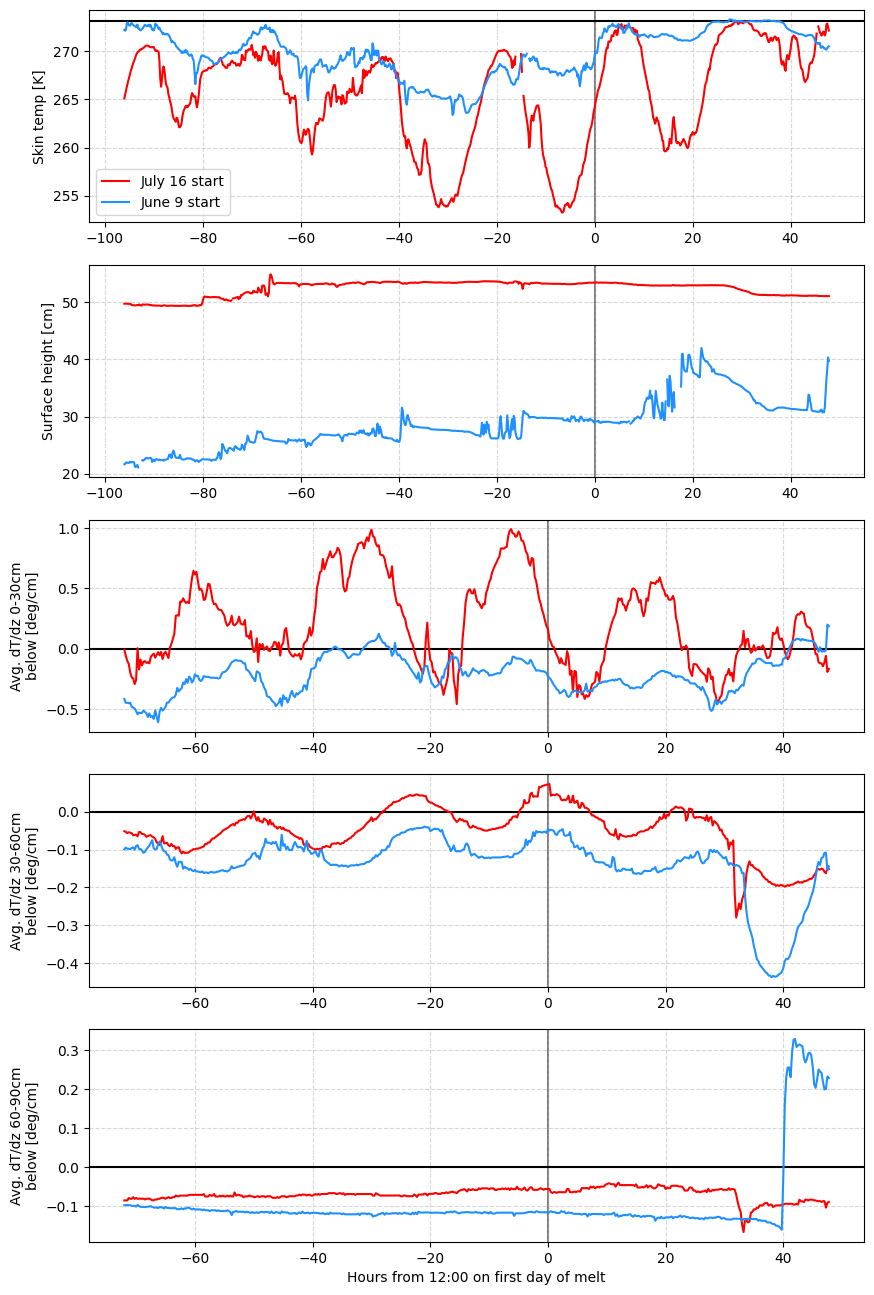

In [297]:
fig, axs = plt.subplots(5, figsize=(10,16))

labels = ['July 16 start','June 9 start']
# labels = ['July 17 start','July 6 start']
# labels = ['July 17 start','June 28 start']

colors = ['r', 'dodgerblue']
axs[0].axhline(y=273.15,c='k')

axs[-3].axhline(y=0,c='k')
axs[-2].axhline(y=0,c='k')
axs[-1].axhline(y=0,c='k')

melt_length = 48

sleight_vars = ['skin_temp','snow_depth']

for i, melt_period in enumerate([big_melt_noon, other_melt_noon]):
    melt_period_idx = np.where((sleigh_dates>=melt_period-datetime.timedelta(hours=24*4))&(sleigh_dates<melt_period+datetime.timedelta(hours=melt_length)))[0]

    hours_since = [(d-melt_period).total_seconds() / 3600. for d in sleight_dates[melt_period_idx]]

    for ax, var in zip(axs.ravel(),sleight_vars):
        ax.plot(hours_since, (asfs_data_lev2[var])[melt_period_idx], label=labels[i],  c=colors[i])

    simba_period_idx = np.where((season_data_solar['dates']>=melt_period-datetime.timedelta(hours=72))&(season_data_solar['dates']<melt_period+datetime.timedelta(hours=melt_length)))[0]
    simba_hours_since = [(d-melt_period).total_seconds() / 3600. for d in season_data_solar['dates'][simba_period_idx]]

    for j, var in enumerate([grad_upper_30, grad_mid_30_60, grad_mid_60_90]):
        axs[len(sleight_vars)+j].plot(simba_hours_since, var[simba_period_idx], label=labels[i],  c=colors[i])

ylabels = ['Skin temp [K]','Surface height [cm]','Avg. dT/dz 0-30cm\nbelow [deg/cm]', 
        'Avg. dT/dz 30-60cm\nbelow [deg/cm]', 'Avg. dT/dz 60-90cm\nbelow [deg/cm]']
for ax, yl in zip(axs.ravel(),ylabels):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(yl)
    ax.axvline(x=0, c='gray', zorder=0)
axs[0].legend(loc='best')
axs[-1].set_xlabel('Hours from 12:00 on first day of melt')
plt.show()

Continuous melt below surface because it was clear w/ more SW that transmits??

Would be good to add precip (important for albedo)

temp gradients instead of average temperatures?

## Compare response/variability/correlation of temperatures/gradients and radiation

In [299]:
# need atm to be on same time steps
sleigh_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in sleigh_dates])
simba_seconds = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in season_data_solar['dates']])

In [316]:
interped_vars = {}

var_names = ['skin_temp','T2m_Tskin','net_rad','net_sw','net_lw','albedo']

for var in var_names:
    var_data = np.ma.masked_invalid(asfs_data_lev2[var])
    f_var = interpolate.interp1d(sleigh_seconds[~var_data.mask], var_data[~var_data.mask], 
                                 fill_value=-999, bounds_error=False)
    
    interp_var = f_var(simba_seconds)
    interped_vars[var] = np.ma.masked_equal(interp_var, -999)



In [320]:
interped_vars['albedo'] = np.ma.masked_greater(interped_vars['albedo'], 1)

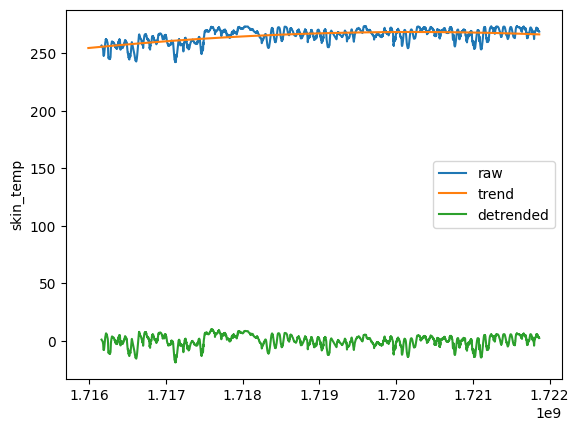

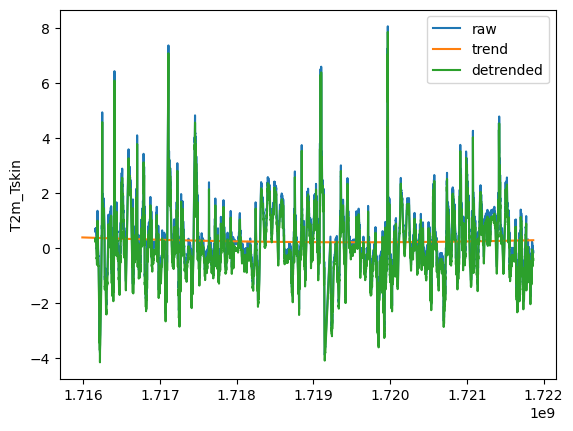

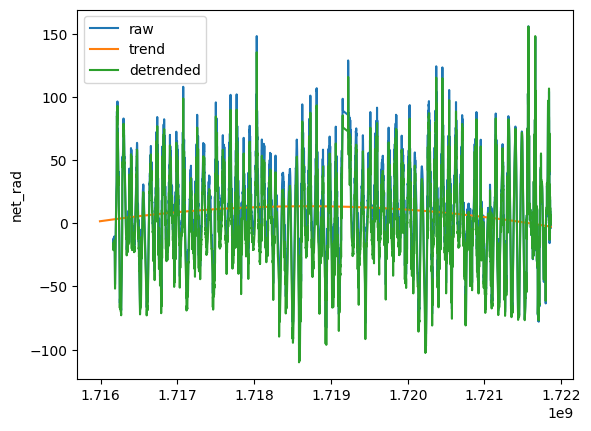

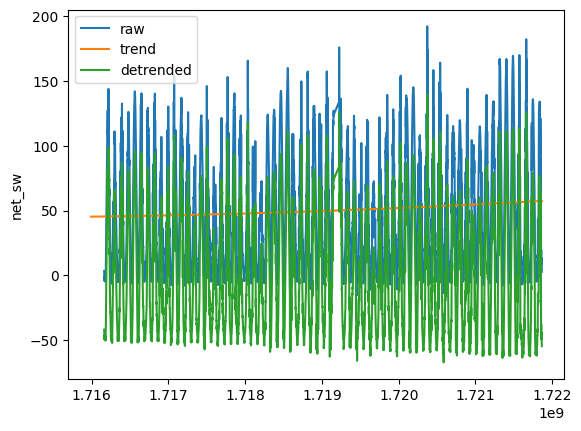

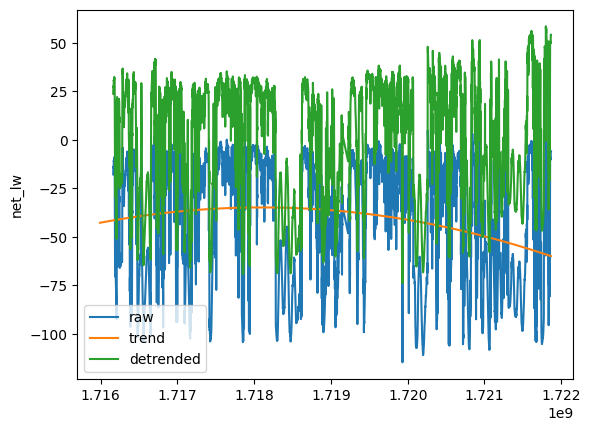

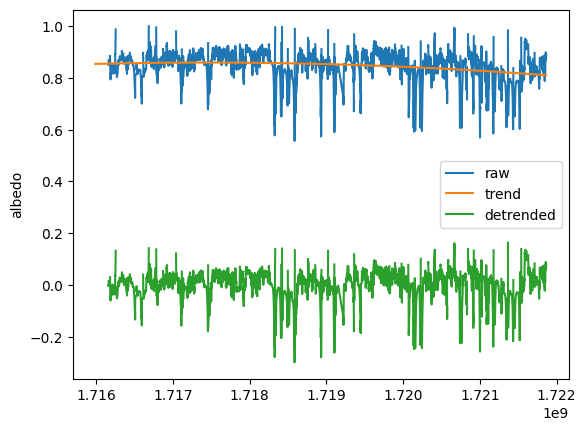

In [324]:
detrended_sleigh_vars = {}

x = simba_seconds

for var in var_names:
    y = interped_vars[var]
    coeff = np.ma.polyfit(x, y, 2)

    # no need to use the original x values here just for visualizing the polynomial
    x_poly = np.linspace(x.min(), x.max())
    y_poly = np.polyval(coeff, x_poly)
    
    # we need the original x values here, so we can remove the trend from all points
    trend = np.polyval(coeff, x)
    t_detrend = y - trend
    # note that simply subtracting the trend might not be enough for other data sets
    # slopes_with_depth.append(coeff[0])

    plt.ylabel(var)
    plt.plot(x, y, label='raw')
    plt.plot(x, trend, label='trend')
    plt.plot(x, t_detrend, label='detrended')
    plt.legend(loc='best')
    plt.show()
    detrended_sleigh_vars[var] = t_detrend

In [322]:
simba_correlations_with_depth = {}

for var in detrended_sleigh_vars:
    detr_data = detrended_sleigh_vars[var]
    
    simba_correlations_with_depth[var] = np.ma.corrcoef(detr_data, detrend_temps[:,:].T)[0][1:]

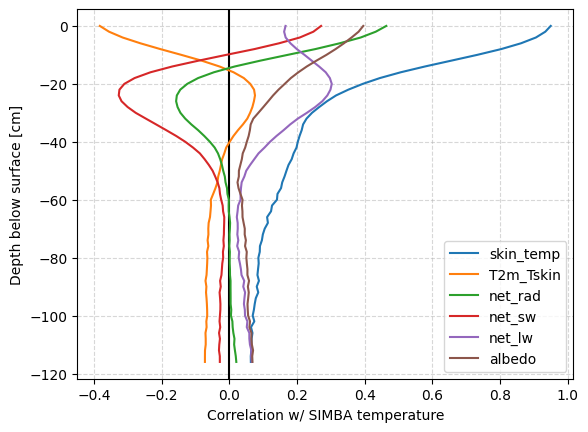

In [323]:
plt.axvline(x=0, c='k')
for var in simba_correlations_with_depth:
    plt.plot(simba_correlations_with_depth[var][~temp_std_full.mask], sub_depths[~temp_std_full.mask], label=var)

plt.ylabel('Depth below surface [cm]')
plt.grid(alpha=.5, ls='--')
plt.legend(loc='best')
plt.xlabel('Correlation w/ SIMBA temperature')
plt.show()

In [ ]:
plt.plot()